### Dowload dataset from Roboflow

In [1]:
# ============================================================
# DOWNLOAD ROBOFLOW DATASET
# ============================================================

%pip install -q roboflow

from roboflow import Roboflow
import os
from pathlib import Path

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
WORKSPACE = "ilovefoods-workspace-qd0ut"
PROJECT = "aggregate_rock-and-sand"
VERSION = 5

DATASET_DIR = Path(r"B:\02_Projects\thesis_final\experiment\data\bronze")

# ------------------------------------------------------------
# Idempotent: skip download when bronze already exists.
# Set ROBOFLOW_API_KEY in the environment to (re)download —
# never commit keys to the repo.
# ------------------------------------------------------------
if (DATASET_DIR / "train" / "images").exists():
    n = len(list((DATASET_DIR / "train" / "images").iterdir()))
    print(f"bronze already exists ({n} train images) — skipping download")
    dataset = None
else:
    rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
    project = rf.workspace(WORKSPACE).project(PROJECT)
    dataset = project.version(VERSION).download(
        model_format="yolo26",
        location=str(DATASET_DIR),
        overwrite=True,
    )

print("\n" + "=" * 70)
print("DOWNLOAD CELL DONE")
print("=" * 70)
print(f"Dataset location: {DATASET_DIR}")

Note: you may need to restart the kernel to use updated packages.
bronze already exists (751 train images) — skipping download

DOWNLOAD CELL DONE
Dataset location: B:\02_Projects\thesis_final\experiment\data\bronze


## 2. Exploratory Data Analysis (Pre-Cleaning)

Standard dataset audit for instance segmentation, following what YOLO/segmentation papers report before cleaning:

![EDA pipeline](assets/eda_pipeline.png)

1. **Dataset summary** — images / instances per split, per-class counts
2. **Class distribution** — imbalance between `gravel` and `sand`
3. **Polygon size** — mask area distribution, COCO small/medium/large buckets, vertex count, **crop-zoom on the smallest masks**
4. **Bounding-box geometry** — width × height scatter, aspect ratio
5. **Spatial distribution** — where object centroids fall in the image
6. **Per-image statistics** — instances per image, image resolutions
7. **Sample inspection** — images with polygon overlays
8. **Cleaning flags** — degenerate / tiny / giant / elongated masks

In [2]:
# ============================================================
# EDA SETUP — parse all YOLO-seg labels into DataFrames
# ============================================================

%pip install -q pandas matplotlib seaborn pyyaml pillow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path
from PIL import Image
from matplotlib.patches import Polygon as MplPolygon

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 80   # was 110 — embedded PNGs balloon the .ipynb file

DATASET_DIR = Path(r"B:\02_Projects\thesis_final\experiment\data\bronze")
SPLITS = ["train", "valid", "test"]

with open(DATASET_DIR / "data.yaml") as f:
    data_yaml = yaml.safe_load(f)
CLASS_NAMES = list(data_yaml["names"])
CLASS_COLORS = dict(zip(CLASS_NAMES, sns.color_palette("tab10", len(CLASS_NAMES))))

def shoelace_area(xs, ys):
    """Polygon area from normalized coords (fraction of image area)."""
    return 0.5 * abs(np.dot(xs, np.roll(ys, 1)) - np.dot(ys, np.roll(xs, 1)))

records, img_records = [], []
for split in SPLITS:
    img_dir, lbl_dir = DATASET_DIR / split / "images", DATASET_DIR / split / "labels"
    for img_path in sorted(img_dir.iterdir()):
        w, h = Image.open(img_path).size
        img_records.append({"split": split, "image": img_path.name, "img_w": w, "img_h": h})
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        n_lines = 0
        if lbl_path.exists():
            for line in lbl_path.read_text().splitlines():
                parts = line.split()
                cls_id = int(parts[0])
                coords = np.array(list(map(float, parts[1:])), dtype=float).reshape(-1, 2)
                xs, ys = coords[:, 0], coords[:, 1]
                x0, y0, x1, y1 = xs.min(), ys.min(), xs.max(), ys.max()
                bw, bh = x1 - x0, y1 - y0
                records.append({
                    "split": split, "image": img_path.name,
                    "class_id": cls_id, "class": CLASS_NAMES[cls_id],
                    "n_vertices": len(coords),
                    "area_norm": shoelace_area(xs, ys),
                    "area_px": shoelace_area(xs, ys) * w * h,
                    "cx": xs.mean(), "cy": ys.mean(),
                    "bbox_w": bw, "bbox_h": bh,
                    "aspect": bw / max(bh, 1e-9),
                    "poly": coords,  # normalized (N,2) — kept for mask inspection cells
                })
                n_lines += 1
        img_records[-1]["n_instances"] = n_lines

df = pd.DataFrame(records)          # one row per annotated instance
df_imgs = pd.DataFrame(img_records) # one row per image

print(f"Parsed {len(df):,} instances on {len(df_imgs):,} images "
      f"across {len(SPLITS)} splits | classes: {CLASS_NAMES}")
df.head()

Note: you may need to restart the kernel to use updated packages.


Parsed 6,078 instances on 1,089 images across 3 splits | classes: ['gravel', 'sand']


,split,image,class_id,class,n_vertices,area_norm,area_px,cx,cy,bbox_w,bbox_h,aspect,poly
0,train,07451999-bdf8-4862-b869-6db57c35f0c1_mp4-0000_...,0,gravel,19,0.058305,30225.5,0.560526,0.340132,0.605556,0.194792,3.108734,"[[0.23703703703703705, 0.23958333333333334], [..."
1,train,07451999-bdf8-4862-b869-6db57c35f0c1_mp4-0001_...,0,gravel,3,0.000010,5.0,0.000617,0.550000,0.001852,0.010417,0.177778,"[[0.001851851851851852, 0.55], [0.0, 0.5447916..."
2,train,07451999-bdf8-4862-b869-6db57c35f0c1_mp4-0001_...,0,gravel,17,0.059861,31032.0,0.512745,0.337561,0.596296,0.200000,2.981481,"[[0.21481481481481482, 0.24791666666666667], [..."
3,train,07451999-bdf8-4862-b869-6db57c35f0c1_mp4-0003_...,0,gravel,25,0.063195,32760.5,0.559037,0.361250,0.601852,0.211458,2.846196,"[[0.2074074074074074, 0.2552083333333333], [0...."
4,train,07451999-bdf8-4862-b869-6db57c35f0c1_mp4-0004_...,0,gravel,21,0.065217,33808.5,0.545062,0.371974,0.609259,0.217708,2.798511,"[[0.19814814814814816, 0.259375], [0.198148148..."


In [3]:
# ============================================================
# 2.1 DATASET SUMMARY — images & instances per split / class
# ============================================================

summary = df_imgs.groupby("split").agg(images=("image", "count")).join(
    df.groupby("split").size().rename("instances")
).join(
    df.groupby("split")["image"].nunique().rename("labeled_images")
)
summary["unlabeled_images"] = summary["images"] - summary["labeled_images"]
summary["instances_per_img"] = (summary["instances"] / summary["images"]).round(2)
print("=== Split summary ===")
display(summary)

print("\n=== Instances per class per split ===")
class_counts = df.pivot_table(index="class", columns="split",
                              values="image", aggfunc="count", fill_value=0)
class_counts["total"] = class_counts.sum(axis=1)
class_counts["share_%"] = (class_counts["total"] / class_counts["total"].sum() * 100).round(1)
display(class_counts)

imbalance = class_counts["total"].max() / class_counts["total"].min()
print(f"Class imbalance ratio (major:minor) = {imbalance:.2f} : 1")

=== Split summary ===


,images,instances,labeled_images,unlabeled_images,instances_per_img
split,,,,,
test,109,577,108,1,5.29
train,751,4264,748,3,5.68
valid,229,1237,228,1,5.40



=== Instances per class per split ===


split,test,train,valid,total,share_%
class,,,,,
gravel,281,2066,561,2908,47.8
sand,296,2198,676,3170,52.2


Class imbalance ratio (major:minor) = 1.09 : 1


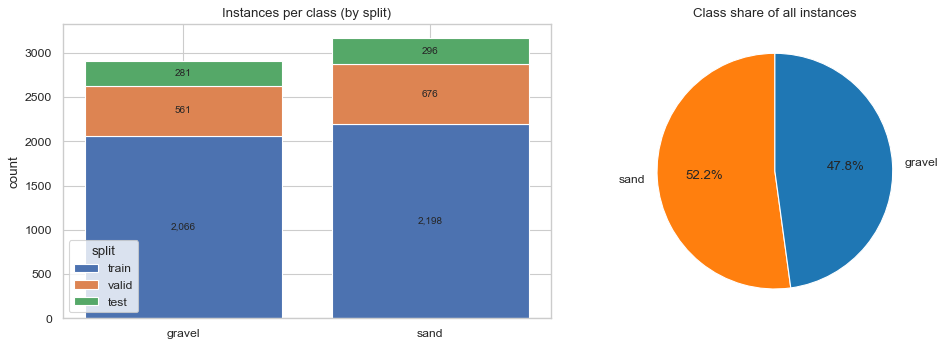

In [4]:
# ============================================================
# 2.2 CLASS DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) instance count per class, stacked by split
ct = df.groupby(["class", "split"]).size().unstack(fill_value=0)[SPLITS]
bottom = np.zeros(len(ct))
for split in SPLITS:
    axes[0].bar(ct.index, ct[split], bottom=bottom, label=split)
    for i, v in enumerate(ct[split]):
        if v:
            axes[0].text(i, bottom[i] + v / 2, f"{v:,}", ha="center", va="center", fontsize=9)
    bottom += ct[split].values
axes[0].set(title="Instances per class (by split)", ylabel="count")
axes[0].legend(title="split")

# (b) share of total — pie shows the imbalance at a glance
totals = df["class"].value_counts()
axes[1].pie(totals, labels=totals.index, autopct="%1.1f%%", startangle=90,
            colors=[CLASS_COLORS[c] for c in totals.index])
axes[1].set_title("Class share of all instances")

plt.tight_layout()
plt.show()

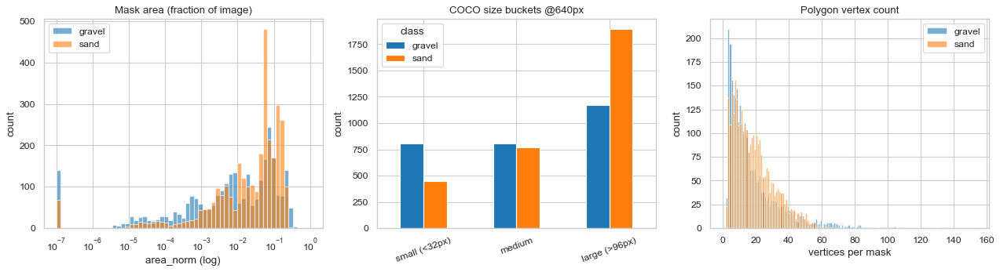

         count     mean      std  min      25%      50%      75%      max
class                                                                    
gravel  2908.0  0.04510  0.06714  0.0  0.00086  0.00922  0.06777  0.38223
sand    3170.0  0.05811  0.05863  0.0  0.00596  0.04718  0.09084  0.28432

Zero / near-zero area masks: 209


In [5]:
# ============================================================
# 2.3 POLYGON SIZE — mask area, COCO size buckets, vertex count
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) mask area as fraction of image (log-x: areas span orders of magnitude)
for cls, g in df.groupby("class"):
    axes[0].hist(g["area_norm"].clip(1e-7), bins=np.logspace(-7, 0, 60),
                 alpha=0.6, label=cls, color=CLASS_COLORS[cls])
axes[0].set_xscale("log")
axes[0].set(title="Mask area (fraction of image)", xlabel="area_norm (log)", ylabel="count")
axes[0].legend()

# (b) COCO-style size buckets at 640x640 equivalent
#     small < 32^2 px, medium 32^2-96^2 px, large > 96^2 px
SIDE = 640
bucket = pd.cut(df["area_norm"] * SIDE**2,
                bins=[0, 32**2, 96**2, np.inf],
                labels=["small (<32px)", "medium", "large (>96px)"])
buckets = df.assign(size_bucket=bucket).groupby(["class", "size_bucket"], observed=True).size().unstack(fill_value=0)
bt = buckets.T
bt.plot(kind="bar", ax=axes[1], color=[CLASS_COLORS[c] for c in bt.columns])
axes[1].set(title="COCO size buckets @640px", xlabel="", ylabel="count")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="class")

# (c) polygon vertex count — annotation granularity / quality proxy
for cls, g in df.groupby("class"):
    axes[2].hist(g["n_vertices"], bins=range(0, int(df["n_vertices"].max()) + 2),
                 alpha=0.6, label=cls, color=CLASS_COLORS[cls])
axes[2].set(title="Polygon vertex count", xlabel="vertices per mask", ylabel="count")
axes[2].legend()

plt.tight_layout()
plt.show()

print(df.groupby("class")["area_norm"].describe().round(5))
print("\nZero / near-zero area masks:", int((df["area_norm"] < 1e-6).sum()))

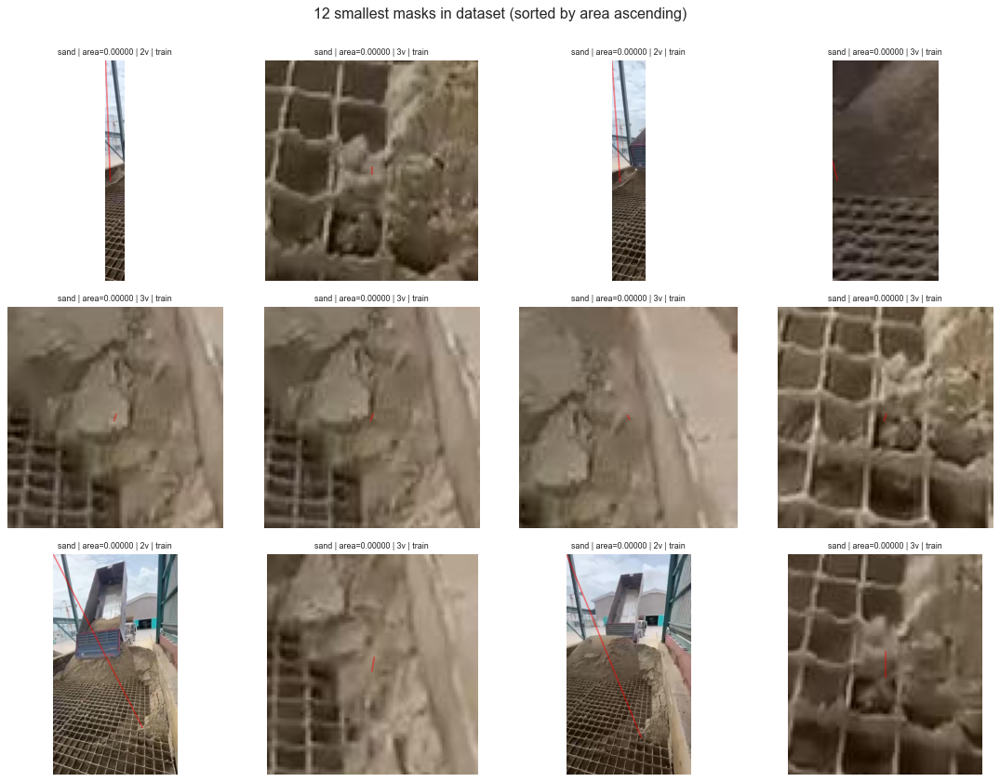

split                                                                                     image class  area_norm  n_vertices
train 0a48349e-f671-436a-8af5-de54f079109f_mp4-0002_jpg.rf.971195cad50e6197c6ad57dfa4044a80.jpg  sand        0.0           2
train 0a48349e-f671-436a-8af5-de54f079109f_mp4-0005_jpg.rf.186030c1b8d6e1044f24df2050ed52f6.jpg  sand        0.0           3
train 0a48349e-f671-436a-8af5-de54f079109f_mp4-0006_jpg.rf.7c4e859a2535edae8fd4092d40b5feb4.jpg  sand        0.0           2
train 0a48349e-f671-436a-8af5-de54f079109f_mp4-0013_jpg.rf.3e973f61e81eb803b3b353f5327e6975.jpg  sand        0.0           3
train 0a48349e-f671-436a-8af5-de54f079109f_mp4-0015_jpg.rf.d38ce010f9c0d0b35c69a2bf310dce07.jpg  sand        0.0           3
train 0a48349e-f671-436a-8af5-de54f079109f_mp4-0015_jpg.rf.d38ce010f9c0d0b35c69a2bf310dce07.jpg  sand        0.0           3
train 0a48349e-f671-436a-8af5-de54f079109f_mp4-0015_jpg.rf.d38ce010f9c0d0b35c69a2bf310dce07.jpg  sand        0.0           3


In [6]:
# ============================================================
# 2.3b SMALLEST MASKS — crop-zoom on the tiniest polygons
#     (are they real grains or annotation noise?)
# ============================================================

N_SHOW = 12          # how many of the smallest masks to show
PAD_FACTOR = 3.0     # crop window = mask bbox * this factor (context around it)

smallest = df.nsmallest(N_SHOW, "area_norm")
ncols = 4
nrows = int(np.ceil(N_SHOW / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))

for ax, (_, r) in zip(axes.flat, smallest.iterrows()):
    img = np.asarray(Image.open(DATASET_DIR / r["split"] / "images" / r["image"]))
    h, w = img.shape[:2]
    poly_px = r["poly"] * [w, h]

    x0, y0 = poly_px[:, 0].min(), poly_px[:, 1].min()
    x1, y1 = poly_px[:, 0].max(), poly_px[:, 1].max()
    pad_x = max((x1 - x0) * PAD_FACTOR, 40)   # >=40px context each way
    pad_y = max((y1 - y0) * PAD_FACTOR, 40)
    cx0, cx1 = int(max(0, x0 - pad_x)), int(min(w, x1 + pad_x))
    cy0, cy1 = int(max(0, y0 - pad_y)), int(min(h, y1 + pad_y))

    ax.imshow(img[cy0:cy1, cx0:cx1], extent=[cx0, cx1, cy1, cy0])
    ax.add_patch(MplPolygon(poly_px, closed=True, fill=True, alpha=0.45,
                            facecolor=CLASS_COLORS[r["class"]],
                            edgecolor="red", linewidth=1.5))
    ax.set_xlim(cx0, cx1); ax.set_ylim(cy1, cy0)
    ax.set_title(f'{r["class"]} | area={r["area_norm"]:.5f} | '
                 f'{r["n_vertices"]}v | {r["split"]}', fontsize=8)
    ax.axis("off")

for ax in axes.flat[N_SHOW:]:
    ax.axis("off")

plt.suptitle(f"{N_SHOW} smallest masks in dataset (sorted by area ascending)", y=1.0)
plt.tight_layout()
plt.show()

print(smallest[["split", "image", "class", "area_norm", "n_vertices"]]
      .to_string(index=False))

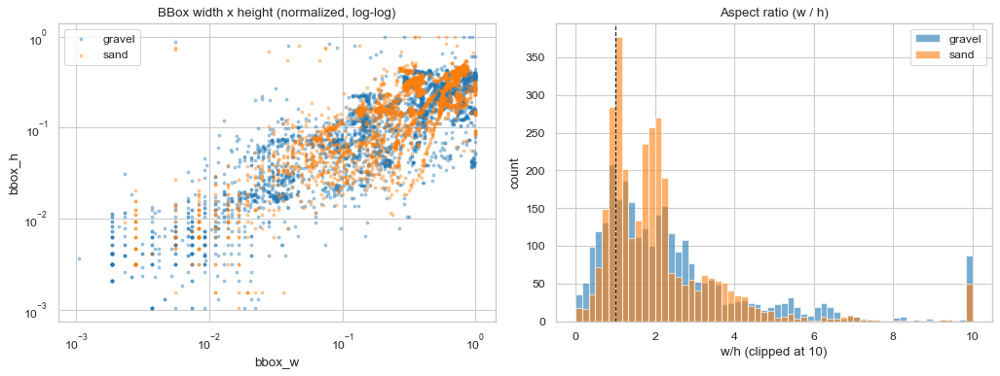

Aspect ratio > 4 (very elongated): 758
Aspect ratio < 0.25 (very tall):   78


In [7]:
# ============================================================
# 2.4 BBOX GEOMETRY — width x height scatter + aspect ratio
#     (the classic YOLO "labels" plot)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for cls, g in df.groupby("class"):
    axes[0].scatter(g["bbox_w"], g["bbox_h"], s=6, alpha=0.35,
                    label=cls, color=CLASS_COLORS[cls])
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set(title="BBox width x height (normalized, log-log)",
            xlabel="bbox_w", ylabel="bbox_h")
axes[0].legend()

for cls, g in df.groupby("class"):
    axes[1].hist(g["aspect"].clip(upper=10), bins=60, alpha=0.6,
                 label=cls, color=CLASS_COLORS[cls])
axes[1].axvline(1.0, color="k", ls="--", lw=1)
axes[1].set(title="Aspect ratio (w / h)", xlabel="w/h (clipped at 10)", ylabel="count")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Aspect ratio > 4 (very elongated):", int((df["aspect"] > 4).sum()))
print("Aspect ratio < 0.25 (very tall):  ", int((df["aspect"] < 0.25).sum()))

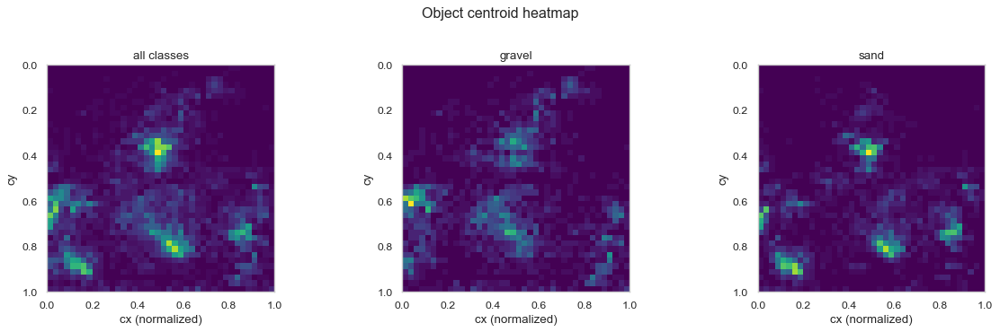

In [8]:
# ============================================================
# 2.5 SPATIAL DISTRIBUTION — where centroids sit in the image
# ============================================================

fig, axes = plt.subplots(1, len(CLASS_NAMES) + 1, figsize=(5 * (len(CLASS_NAMES) + 1), 4.5))

axes[0].hist2d(df["cx"], df["cy"], bins=40, range=[[0, 1], [0, 1]], cmap="viridis")
axes[0].set_title("all classes")

for ax, (cls, g) in zip(axes[1:], df.groupby("class")):
    ax.hist2d(g["cx"], g["cy"], bins=40, range=[[0, 1], [0, 1]], cmap="viridis")
    ax.set_title(cls)

for ax in axes:
    ax.set(xlabel="cx (normalized)", ylabel="cy", aspect="equal")
    ax.invert_yaxis()  # image coords: y=0 at top

plt.suptitle("Object centroid heatmap", y=1.02)
plt.tight_layout()
plt.show()

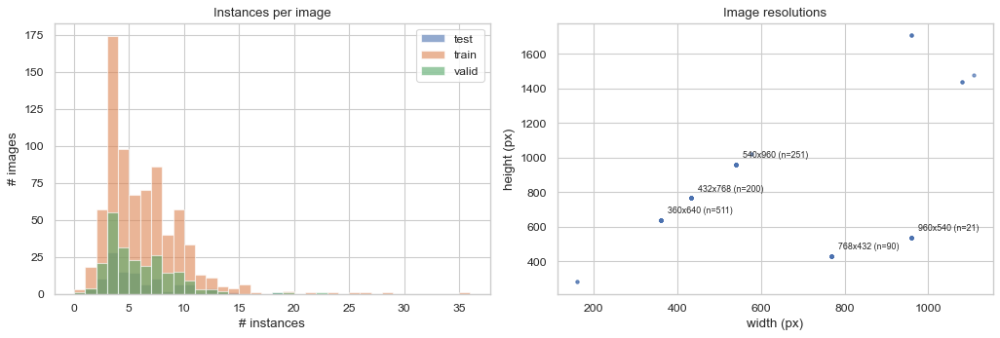

Images with ZERO instances: 5
img_w  img_h
360    640      511
540    960      251
432    768      200
768    432       90
960    540       21
       1706       5
1080   1440       4
160    284        3
576    1024       2
1108   1477       2
dtype: int64


In [9]:
# ============================================================
# 2.6 PER-IMAGE STATS — instances per image + image resolutions
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for split, g in df_imgs.groupby("split"):
    axes[0].hist(g["n_instances"], bins=range(0, int(df_imgs["n_instances"].max()) + 2),
                 alpha=0.6, label=split)
axes[0].set(title="Instances per image", xlabel="# instances", ylabel="# images")
axes[0].legend()

axes[1].scatter(df_imgs["img_w"], df_imgs["img_h"], s=8, alpha=0.4)
axes[1].set(title="Image resolutions", xlabel="width (px)", ylabel="height (px)")
for (w, h), n in df_imgs.groupby(["img_w", "img_h"]).size().nlargest(5).items():
    axes[1].annotate(f"{w}x{h} (n={n})", (w, h), textcoords="offset points",
                     xytext=(6, 6), fontsize=8)

plt.tight_layout()
plt.show()

print("Images with ZERO instances:", int((df_imgs["n_instances"] == 0).sum()))
print(df_imgs.groupby(["img_w", "img_h"]).size().sort_values(ascending=False).head(10))

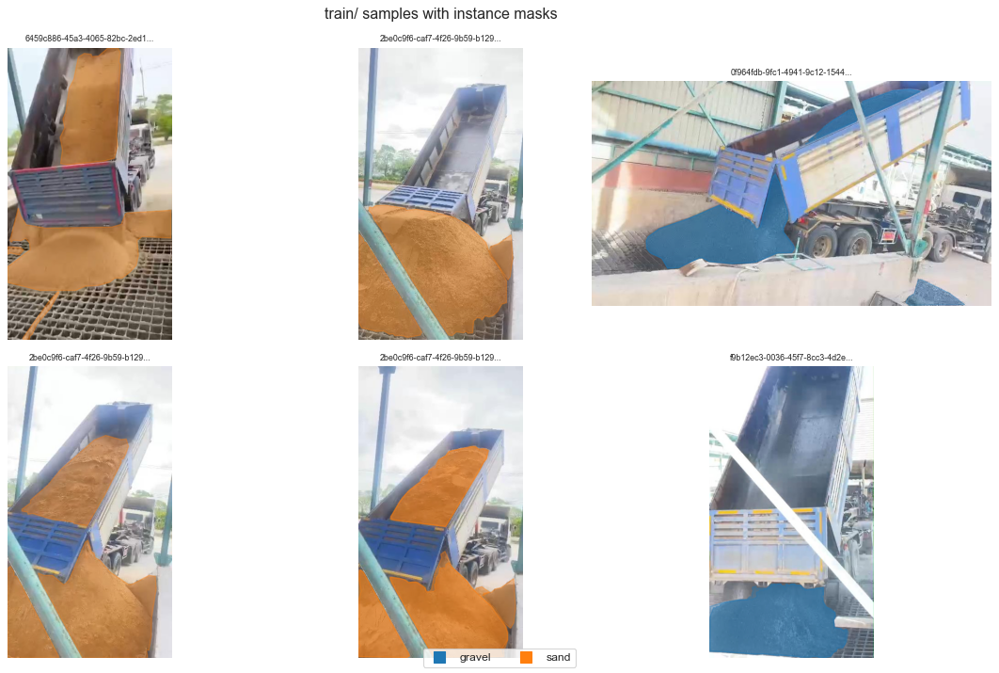

In [10]:
# ============================================================
# 2.7 SAMPLE INSPECTION — images with polygon overlays
# ============================================================

N_SHOW = 6
sample = (df_imgs[df_imgs["split"] == "train"]
          .sample(N_SHOW, random_state=42))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = np.asarray(Image.open(DATASET_DIR / "train" / "images" / row["image"]))
    h, w = img.shape[:2]
    ax.imshow(img)
    for line in (DATASET_DIR / "train" / "labels" / (Path(row["image"]).stem + ".txt")
                 ).read_text().splitlines():
        parts = line.split()
        cls = CLASS_NAMES[int(parts[0])]
        coords = np.array(list(map(float, parts[1:]))).reshape(-1, 2) * [w, h]
        ax.add_patch(MplPolygon(coords, closed=True, fill=True, alpha=0.35,
                                facecolor=CLASS_COLORS[cls],
                                edgecolor=CLASS_COLORS[cls], linewidth=1.2))
    ax.set_title(row["image"][:28] + "...", fontsize=8)
    ax.axis("off")

handles = [plt.Line2D([0], [0], marker="s", ls="", markersize=10,
                      color=CLASS_COLORS[c], label=c) for c in CLASS_NAMES]
fig.legend(handles=handles, loc="lower center", ncol=len(CLASS_NAMES))
plt.suptitle("train/ samples with instance masks")
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 2.8 CLEANING FLAGS — auto-detected issues to fix before training
# ============================================================

flags = {
    "zero/near-zero area masks (degenerate)": df["area_norm"] < 1e-6,
    "tiny masks (<0.1% of image)":          df["area_norm"] < 0.001,
    "huge masks (>50% of image)":           df["area_norm"] > 0.5,
    "very elongated (aspect>4 or <0.25)":   (df["aspect"] > 4) | (df["aspect"] < 0.25),
    "very few vertices (<5, coarse mask)":  df["n_vertices"] < 5,
    "centroid outside image bounds":        (df["cx"] < 0) | (df["cx"] > 1) |
                                          (df["cy"] < 0) | (df["cy"] > 1),
}
flag_report = pd.DataFrame(
    {k: [int(v.sum()), f"{v.mean() * 100:.2f}%"] for k, v in flags.items()},
    index=["count", "pct_of_instances"],
).T
display(flag_report)

unlabeled = df_imgs[df_imgs["n_instances"] == 0]
print(f"Images with no labels: {len(unlabeled)}")
if len(unlabeled):
    display(unlabeled[["split", "image"]].head(20))

# per-image listing of the worst offenders for manual review
bad_idx = flags["zero/near-zero area masks (degenerate)"] | flags["tiny masks (<0.1% of image)"]
worst = df[bad_idx].groupby(["split", "image"]).size().sort_values(ascending=False)
print("\nImages containing degenerate/tiny masks:")
display(worst.head(20))

,count,pct_of_instances
zero/near-zero area masks (degenerate),209,3.44%
tiny masks (<0.1% of image),1085,17.85%
huge masks (>50% of image),0,0.00%
very elongated (aspect>4 or <0.25),836,13.75%
"very few vertices (<5, coarse mask)",705,11.60%
centroid outside image bounds,0,0.00%


Images with no labels: 5


,split,image
244,train,2be0c9f6-caf7-4f26-9b59-b1299865a721_mp4-0035_...
592,train,96ecd4fe-5910-4cd4-8a24-11ed20aab3b7_mp4-0060_...
594,train,96ecd4fe-5910-4cd4-8a24-11ed20aab3b7_mp4-0063_...
925,valid,96ecd4fe-5910-4cd4-8a24-11ed20aab3b7_mp4-0059_...
1063,test,96ecd4fe-5910-4cd4-8a24-11ed20aab3b7_mp4-0027_...



Images containing degenerate/tiny masks:


split  image                                                                                    
train  9056e676-f14d-410c-9dc7-c5686b3fca04_jpg.rf.6fc669c89bf6cb1267ccf00e86958e00.jpg             21
       b029e315-2e53-4152-a536-1adea99e32f7_mp4-0011_jpg.rf.34d70b2b31c437706f543b913d4782e9.jpg    19
       6f40fbbd-891e-434b-a1ec-365668a5ae66_mp4-0037_jpg.rf.ced76ca9b54ca7e4a8c44b7eff4f569d.jpg    15
       6f40fbbd-891e-434b-a1ec-365668a5ae66_mp4-0040_jpg.rf.5383ffa84007b489fff44eef2f5a8f25.jpg    15
       c6f16e4e-55cb-4abc-91ea-0d01ae0d6d28_jpg.rf.c194075dea18c914988161f0f09163d6.jpg             14
       6f40fbbd-891e-434b-a1ec-365668a5ae66_mp4-0044_jpg.rf.c83f54d20d9163951235283fc9ca78ac.jpg    12
test   2be0c9f6-caf7-4f26-9b59-b1299865a721_mp4-0077_jpg.rf.d9e774746ceecd84835688eccb8151ff.jpg    11
train  b029e315-2e53-4152-a536-1adea99e32f7_mp4-0015_jpg.rf.0c0bbfc5cd727794a3cd6709cb8c5132.jpg    11
test   8f435cb5-02c7-452a-a971-cef315681c19_mp4-0009_jpg.rf.ac7886e44ba21347e97

## 3. Overlap & Merge Analysis (auto-label duplicates)

Roboflow auto-labeling stacked 2–5 polygons on the same physical object. Best practice from
FiftyOne's duplicate-annotation recipe and mask-NMS tooling:

- detect duplicates via **pairwise mask overlap within the same image**, same class first
- two metrics matter: **IoU** (intersection / union) catches equal-size duplicates,
  **IoMin** (intersection / smaller area) catches nested duplicates where one polygon
  sits inside another
- then **cluster** overlapping polygons (union-find) and **merge** each cluster into
  one polygon via `shapely.unary_union`

This section only **visualizes** the overlap structure — no labels are modified yet.
Cleaning order (decided after seeing these plots):

1. drop degenerate + tiny noise masks first (they must never merge into real masks)
2. cluster + merge the remaining same-position duplicates
3. write cleaned labels to `data/silver/`

In [12]:
# ============================================================
# 3.1 OVERLAP DETECTION — pairwise mask IoU & IoMin per image
# ============================================================
# IoU   = intersection / union        -> catches equal-size duplicates
# IoMin = intersection / min(area)    -> catches nested duplicates (1 inside another)
# same_class flag separates "stacked autolabel duplicates" from
# genuine gravel-vs-sand neighbours that just touch.

%pip install -q shapely

from itertools import combinations
from shapely.geometry import Polygon
from shapely.validation import make_valid

def to_geom(poly):
    """Shapely geometry from normalized coords.
    Degenerate masks (<3 points) and invalid rings -> empty geometry
    (area 0, never overlaps) so they can't poison the overlap graph."""
    try:
        if len(poly) < 3:
            return Polygon()
        g = Polygon(poly)
        return g if g.is_valid else make_valid(g)
    except Exception:
        return Polygon()

GEOMS = {i: to_geom(r["poly"]) for i, r in df.iterrows()}

pairs = []
for (split, img), gdf in df.groupby(["split", "image"]):
    idxs = gdf.index.tolist()
    for a, b in combinations(idxs, 2):
        ga, gb = GEOMS[a], GEOMS[b]
        if ga.is_empty or gb.is_empty:
            continue
        # cheap bbox reject before expensive intersection
        if ga.bounds[2] < gb.bounds[0] or gb.bounds[2] < ga.bounds[0] or \
           ga.bounds[3] < gb.bounds[1] or gb.bounds[3] < ga.bounds[1]:
            continue
        inter = ga.intersection(gb).area
        min_a = min(ga.area, gb.area)
        if inter <= 0 or min_a <= 0:
            continue
        iou = inter / ga.union(gb).area
        iomin = inter / min_a
        pairs.append({
            "split": split, "image": img,
            "i": a, "j": b,
            "class_i": df.at[a, "class"], "class_j": df.at[b, "class"],
            "same_class": df.at[a, "class_id"] == df.at[b, "class_id"],
            "iou": iou, "iomin": iomin, "inter": inter,
        })

df_ov = pd.DataFrame(pairs)
print(f"Overlapping pairs found: {len(df_ov):,}")
if len(df_ov):
    print(df_ov.groupby("same_class")[["iou", "iomin"]].describe().round(3))

Note: you may need to restart the kernel to use updated packages.


Overlapping pairs found: 2,089
               iou                                                 iomin  \
             count   mean   std  min    25%    50%    75%    max   count   
same_class                                                                 
True        2089.0  0.493  0.42  0.0  0.004  0.499  0.953  0.998  2089.0   

                                                        
             mean   std  min    25%    50%    75%  max  
same_class                                              
True        0.808  0.37  0.0  0.965  0.994  0.999  1.0  


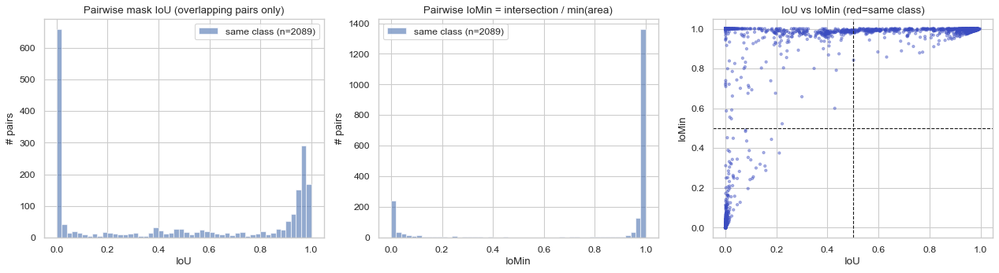

Same-class pairs above threshold:
  iou > 0.3: 1222
  iou > 0.5: 1044
  iou > 0.7: 894
  iou > 0.9: 736
  iomin > 0.3: 1711
  iomin > 0.5: 1689
  iomin > 0.7: 1678
  iomin > 0.9: 1640


In [13]:
# ============================================================
# 3.2 OVERLAP SCORE DISTRIBUTION — pick the merge threshold
# ============================================================
# Look for the elbow: autolabel duplicates cluster at high IoMin,
# real touching neighbours sit at low overlap.

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for same, g in df_ov.groupby("same_class"):
    lbl = "same class" if same else "cross class"
    axes[0].hist(g["iou"], bins=np.linspace(0, 1, 51), alpha=0.6,
                 label=f"{lbl} (n={len(g)})")
axes[0].set(title="Pairwise mask IoU (overlapping pairs only)",
            xlabel="IoU", ylabel="# pairs")
axes[0].legend()

for same, g in df_ov.groupby("same_class"):
    lbl = "same class" if same else "cross class"
    axes[1].hist(g["iomin"], bins=np.linspace(0, 1, 51), alpha=0.6,
                 label=f"{lbl} (n={len(g)})")
axes[1].set(title="Pairwise IoMin = intersection / min(area)",
            xlabel="IoMin", ylabel="# pairs")
axes[1].legend()

sc = axes[2].scatter(df_ov["iou"], df_ov["iomin"],
                     c=df_ov["same_class"], cmap="coolwarm", s=8, alpha=0.4)
axes[2].set(title="IoU vs IoMin (red=same class)", xlabel="IoU", ylabel="IoMin")
axes[2].axvline(0.5, color="k", ls="--", lw=1)
axes[2].axhline(0.5, color="k", ls="--", lw=1)

plt.tight_layout()
plt.show()

# candidate duplicate counts at common thresholds (same-class pairs)
print("Same-class pairs above threshold:")
for m in ["iou", "iomin"]:
    for t in (0.3, 0.5, 0.7, 0.9):
        n = int(((df_ov["same_class"]) & (df_ov[m] > t)).sum())
        print(f"  {m} > {t}: {n}")

Rule: iomin >= 0.5, same_class=True
Clusters: 932 | instances involved: 2356
Cluster size histogram: {2: 667, 3: 164, 4: 41, 5: 34, 6: 8, 7: 9, 8: 4, 9: 2, 10: 1, 12: 1, 13: 1}


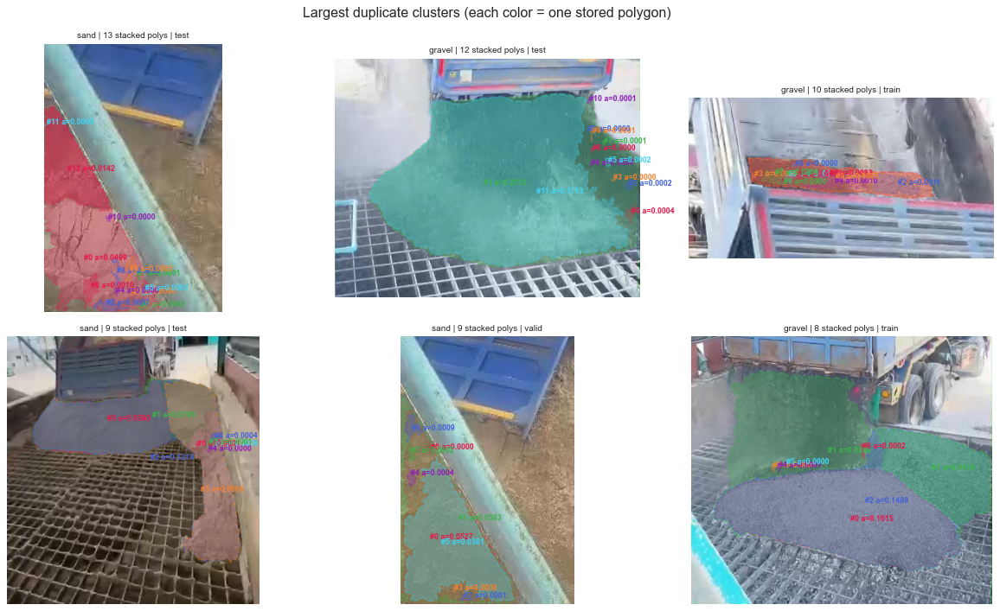

In [14]:
# ============================================================
# 3.3 OVERLAP CLUSTERS — union-find grouping + visual check
# ============================================================
# Provisional rule for VISUALIZATION ONLY: same-class pair with
# IoMin >= 0.5 links two masks -> connected components = candidate
# duplicate clusters (one physical object, 2-5 stacked polygons).

CLUSTER_METRIC = "iomin"   # "iou" or "iomin"
CLUSTER_THR    = 0.5
SAME_CLASS_ONLY = True

def union_find_clusters(edge_df):
    parent = {}
    def find(x):
        parent.setdefault(x, x)
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    for _, r in edge_df.iterrows():
        pa, pb = find(r["i"]), find(r["j"])
        if pa != pb:
            parent[pa] = pb
    clusters = {}
    for x in parent:
        clusters.setdefault(find(x), []).append(x)
    return [c for c in clusters.values() if len(c) > 1]

edges = df_ov[df_ov[CLUSTER_METRIC] >= CLUSTER_THR]
if SAME_CLASS_ONLY:
    edges = edges[edges["same_class"]]
clusters = union_find_clusters(edges)
clusters.sort(key=len, reverse=True)

print(f"Rule: {CLUSTER_METRIC} >= {CLUSTER_THR}, same_class={SAME_CLASS_ONLY}")
print(f"Clusters: {len(clusters)} | instances involved: {sum(len(c) for c in clusters)}")
print("Cluster size histogram:", pd.Series([len(c) for c in clusters]).value_counts().sort_index().to_dict())

# ---- visualize the biggest clusters -------------------------------
N_CLUSTERS = min(6, len(clusters))
MEMBER_COLORS = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4", "#42d4f4"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, members in zip(axes.flat, clusters[:N_CLUSTERS]):
    r0 = df.loc[members[0]]
    img = np.asarray(Image.open(DATASET_DIR / r0["split"] / "images" / r0["image"]))
    h, w = img.shape[:2]

    polys_px = [df.at[m, "poly"] * [w, h] for m in members]
    all_x = np.concatenate([p[:, 0] for p in polys_px])
    all_y = np.concatenate([p[:, 1] for p in polys_px])
    pad = 60
    cx0, cx1 = int(max(0, all_x.min() - pad)), int(min(w, all_x.max() + pad))
    cy0, cy1 = int(max(0, all_y.min() - pad)), int(min(h, all_y.max() + pad))

    ax.imshow(img[cy0:cy1, cx0:cx1], extent=[cx0, cx1, cy1, cy0])
    for k, (m, ppx) in enumerate(zip(members, polys_px)):
        ax.add_patch(MplPolygon(ppx, closed=True, fill=True, alpha=0.3,
                                facecolor=MEMBER_COLORS[k % len(MEMBER_COLORS)],
                                edgecolor=MEMBER_COLORS[k % len(MEMBER_COLORS)],
                                linewidth=1.8, linestyle="--"))
        ax.annotate(f"#{k} a={df.at[m,'area_norm']:.4f}",
                    (ppx[:, 0].mean(), ppx[:, 1].mean()),
                    fontsize=8, color=MEMBER_COLORS[k % len(MEMBER_COLORS)],
                    fontweight="bold")
    ax.set_xlim(cx0, cx1); ax.set_ylim(cy1, cy0)
    ax.set_title(f"{r0['class']} | {len(members)} stacked polys | {r0['split']}", fontsize=9)
    ax.axis("off")

for ax in axes.flat[N_CLUSTERS:]:
    ax.axis("off")
plt.suptitle("Largest duplicate clusters (each color = one stored polygon)")
plt.tight_layout()
plt.show()

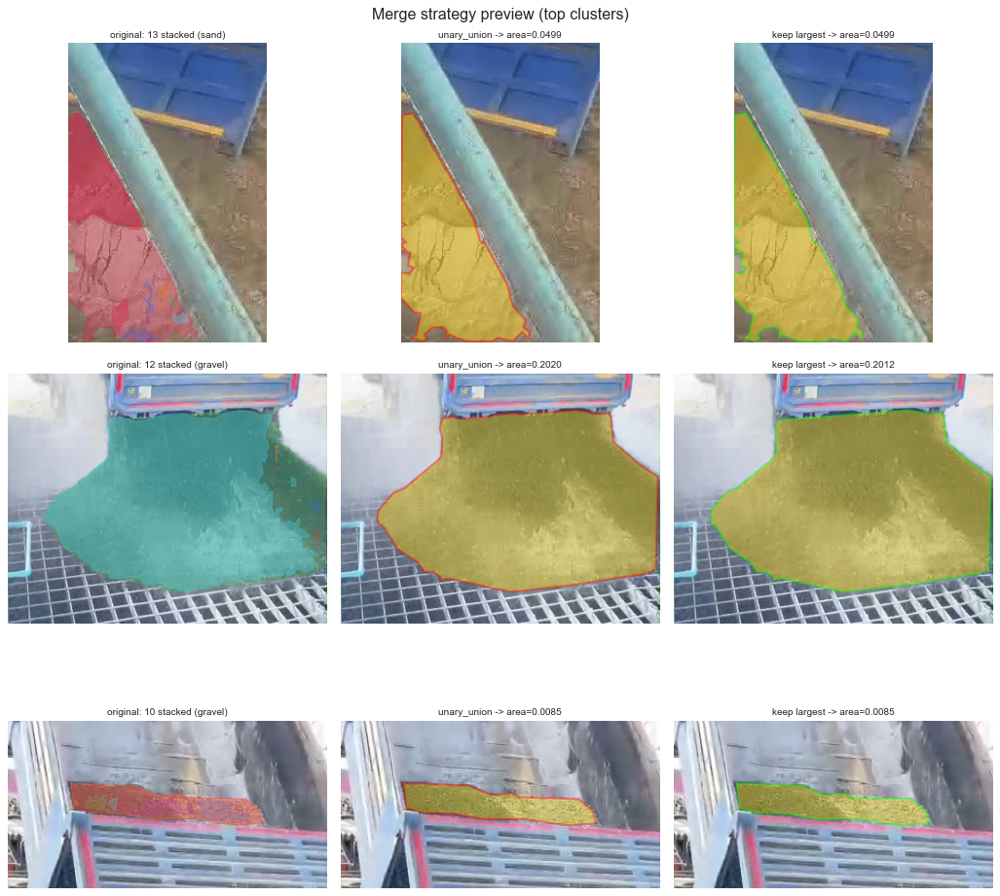

In [15]:
# ============================================================
# 3.4 MERGE STRATEGY PREVIEW — union vs keep-largest vs keep-all
# ============================================================
# For each top cluster, compare what "1 polygon" would look like:
#   (a) original stacked polys  (b) unary_union outline  (c) largest only
# union    -> preserves full extent, may "grow" the mask
# largest  -> tightest, discards extra coverage from smaller dupes

from shapely.ops import unary_union

N_PREVIEW = min(3, len(clusters))
fig, axes = plt.subplots(N_PREVIEW, 3, figsize=(13, 4.2 * N_PREVIEW))
if N_PREVIEW == 1:
    axes = axes[None, :]

for row, members in enumerate(clusters[:N_PREVIEW]):
    r0 = df.loc[members[0]]
    img = np.asarray(Image.open(DATASET_DIR / r0["split"] / "images" / r0["image"]))
    h, w = img.shape[:2]

    geoms = [GEOMS[m] for m in members]
    union_g = unary_union(geoms)
    if union_g.geom_type == "MultiPolygon":
        union_g = max(union_g.geoms, key=lambda g: g.area)
    biggest_m = max(members, key=lambda m: df.at[m, "area_norm"])

    bx0 = min(g.bounds[0] for g in geoms); by0 = min(g.bounds[1] for g in geoms)
    bx1 = max(g.bounds[2] for g in geoms); by1 = max(g.bounds[3] for g in geoms)
    pad = 60
    cx0, cx1 = int(max(0, bx0 * w - pad)), int(min(w, bx1 * w + pad))
    cy0, cy1 = int(max(0, by0 * h - pad)), int(min(h, by1 * h + pad))

    def setup(ax, title):
        ax.imshow(img[cy0:cy1, cx0:cx1], extent=[cx0, cx1, cy1, cy0])
        ax.set_xlim(cx0, cx1); ax.set_ylim(cy1, cy0)
        ax.set_title(title, fontsize=9); ax.axis("off")

    # (a) originals
    setup(axes[row, 0], f"original: {len(members)} stacked ({r0['class']})")
    for k, m in enumerate(members):
        axes[row, 0].add_patch(MplPolygon(
            df.at[m, "poly"] * [w, h], closed=True, fill=True, alpha=0.3,
            facecolor=MEMBER_COLORS[k % 6], edgecolor=MEMBER_COLORS[k % 6]))

    # (b) union
    setup(axes[row, 1], f"unary_union -> area={union_g.area:.4f}")
    ux, uy = union_g.exterior.xy
    axes[row, 1].add_patch(MplPolygon(
        np.c_[np.array(ux) * w, np.array(uy) * h], closed=True, fill=True,
        alpha=0.4, facecolor="gold", edgecolor="red", linewidth=2))

    # (c) keep largest
    setup(axes[row, 2], f"keep largest -> area={df.at[biggest_m,'area_norm']:.4f}")
    axes[row, 2].add_patch(MplPolygon(
        df.at[biggest_m, "poly"] * [w, h], closed=True, fill=True,
        alpha=0.4, facecolor="gold", edgecolor="lime", linewidth=2))

plt.suptitle("Merge strategy preview (top clusters)")
plt.tight_layout()
plt.show()

valid tiny masks (<0.001 of image): 876
  inside duplicate clusters (will merge into big mask): 303
  standalone (drop = lose them entirely):               573

by class:
class
gravel    463
sand      110
dtype: int64


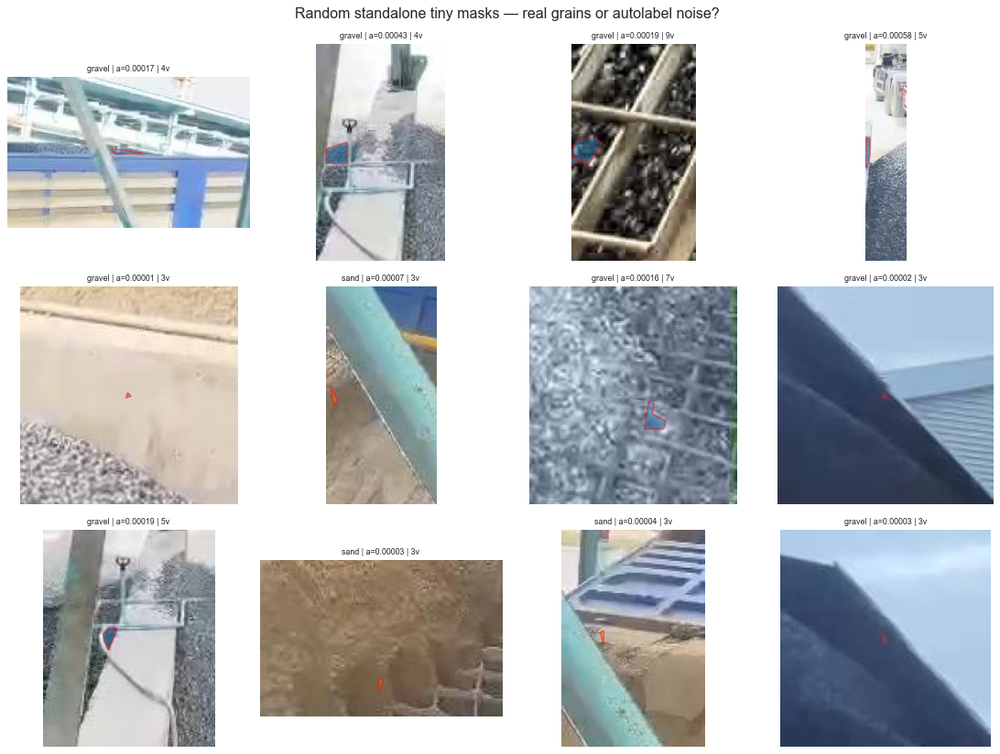

In [16]:
# ============================================================
# 3.5 TINY MASKS IN CONTEXT — standalone noise vs real small grains
# ============================================================
# Decide the tiny-mask rule from evidence:
#   - tiny AND inside a duplicate cluster -> merges into the big mask anyway
#   - tiny AND standalone                 -> candidate noise, needs eyeball check

MIN_AREA = 0.001   # 0.1% of image — same threshold as the 2.8 flag

is_deg = ((df["n_vertices"] < 3)
          | (df["area_norm"] <= 1e-9)
          | pd.Series([GEOMS[i].is_empty for i in df.index], index=df.index))
tiny_valid = (~is_deg) & (df["area_norm"] < MIN_AREA)
clustered_idx = {m for c in clusters for m in c}
tiny_in_cluster = tiny_valid & df.index.isin(clustered_idx)
tiny_standalone = tiny_valid & ~df.index.isin(clustered_idx)

print(f"valid tiny masks (<{MIN_AREA} of image): {int(tiny_valid.sum())}")
print(f"  inside duplicate clusters (will merge into big mask): {int(tiny_in_cluster.sum())}")
print(f"  standalone (drop = lose them entirely):               {int(tiny_standalone.sum())}")
print("\nby class:")
print(df[tiny_standalone].groupby("class").size())

# ---- eyeball a random sample of standalone tiny masks ---------
N_SHOW = 12
rng = np.random.default_rng(7)
pool = df[tiny_standalone].sample(min(N_SHOW, int(tiny_standalone.sum())), random_state=7)

ncols = 4
nrows = int(np.ceil(len(pool) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, (_, r) in zip(axes, pool.iterrows()):
    img = np.asarray(Image.open(DATASET_DIR / r["split"] / "images" / r["image"]))
    h, w = img.shape[:2]
    poly_px = np.asarray(r["poly"]) * [w, h]
    x0, y0, x1, y1 = poly_px[:,0].min(), poly_px[:,1].min(), poly_px[:,0].max(), poly_px[:,1].max()
    pad_x = max((x1 - x0) * 3.0, 60); pad_y = max((y1 - y0) * 3.0, 60)
    cx0, cx1 = int(max(0, x0 - pad_x)), int(min(w, x1 + pad_x))
    cy0, cy1 = int(max(0, y0 - pad_y)), int(min(h, y1 + pad_y))
    ax.imshow(img[cy0:cy1, cx0:cx1], extent=[cx0, cx1, cy1, cy0])
    ax.add_patch(MplPolygon(poly_px, closed=True, fill=True, alpha=0.45,
                            facecolor=CLASS_COLORS[r["class"]], edgecolor="red", lw=1.5))
    ax.set_xlim(cx0, cx1); ax.set_ylim(cy1, cy0)
    ax.set_title(f'{r["class"]} | a={r["area_norm"]:.5f} | {r["n_vertices"]}v', fontsize=8)
    ax.axis("off")
for ax in axes[len(pool):]:
    ax.axis("off")

plt.suptitle("Random standalone tiny masks — real grains or autolabel noise?")
plt.tight_layout()
plt.show()

images containing >=1 tiny mask : 359 / 1089
images containing >=5 tiny masks: 60

top 10 by tiny-mask count:
split  image                                                                                    
train  9056e676-f14d-410c-9dc7-c5686b3fca04_jpg.rf.6fc669c89bf6cb1267ccf00e86958e00.jpg             21
       c6f16e4e-55cb-4abc-91ea-0d01ae0d6d28_jpg.rf.c194075dea18c914988161f0f09163d6.jpg             14
test   2be0c9f6-caf7-4f26-9b59-b1299865a721_mp4-0077_jpg.rf.d9e774746ceecd84835688eccb8151ff.jpg    11
       8f435cb5-02c7-452a-a971-cef315681c19_mp4-0009_jpg.rf.ac7886e44ba21347e97826dc8afd6926.jpg    10
valid  d56fcb3c-0531-4696-8b67-2645d89e4a7f_mp4-0014_jpg.rf.60cd05dde1aedc87fe8b13c56d12b94f.jpg    10
train  b029e315-2e53-4152-a536-1adea99e32f7_mp4-0015_jpg.rf.0c0bbfc5cd727794a3cd6709cb8c5132.jpg     8
       6f40fbbd-891e-434b-a1ec-365668a5ae66_mp4-0040_jpg.rf.5383ffa84007b489fff44eef2f5a8f25.jpg     6
       8f435cb5-02c7-452a-a971-cef315681c19_mp4-0027_jpg.rf.51ce7156ca03

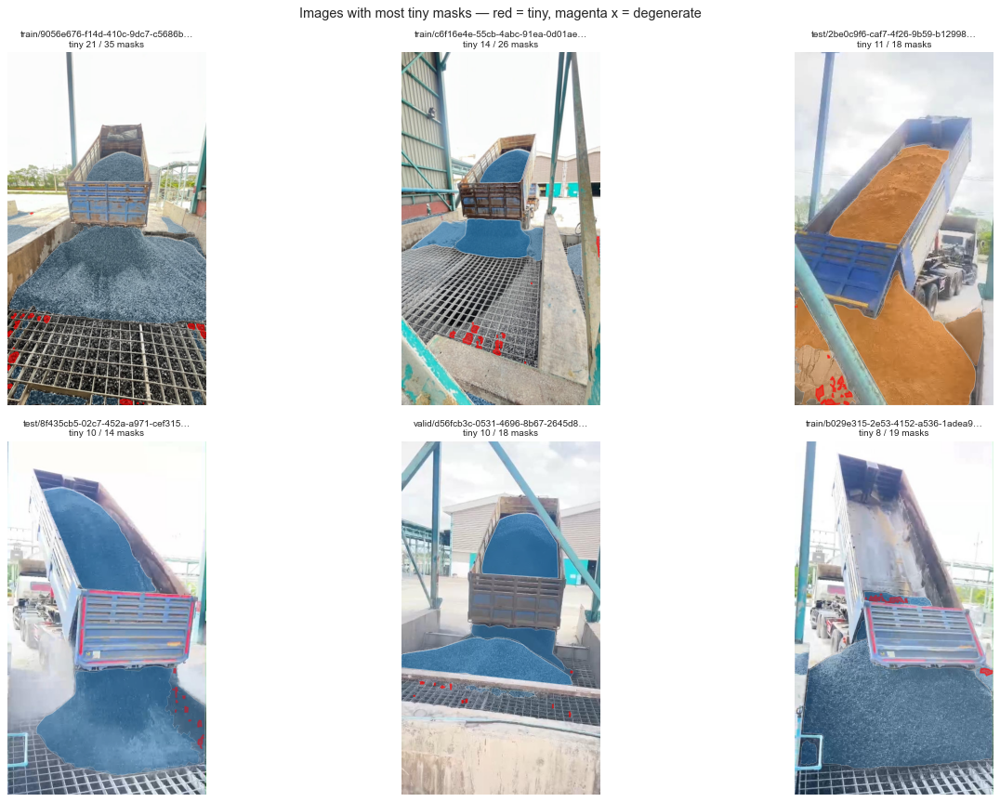

In [17]:
# ============================================================
# 3.6 NOISE HOTSPOTS — which images carry the most tiny masks
# ============================================================
# Uses `tiny_valid` / `is_deg` / `MIN_AREA` from cell 3.5.
# red fill = tiny mask (<MIN_AREA) | magenta x = degenerate point/line
# class color = normal mask

tiny_img = (df[tiny_valid].groupby(["split", "image"]).size()
            .sort_values(ascending=False))
print(f"images containing >=1 tiny mask : {(tiny_img > 0).sum()} / {len(df_imgs)}")
print(f"images containing >=5 tiny masks: {(tiny_img >= 5).sum()}")
print("\ntop 10 by tiny-mask count:")
print(tiny_img.head(10).to_string())

N_SHOW = 6
top = tiny_img.head(N_SHOW).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (split, img) in zip(axes.ravel(), top):
    im = np.asarray(Image.open(DATASET_DIR / split / "images" / img))
    h, w = im.shape[:2]
    ax.imshow(im)
    sub = df[(df["split"] == split) & (df["image"] == img)]
    n_t = 0
    for _, r in sub.iterrows():
        px = np.asarray(r["poly"]) * [w, h]
        if len(r["poly"]) < 3:
            ax.scatter(px[:, 0], px[:, 1], s=50, c="magenta", marker="x", lw=2)
            continue
        is_t = (not is_deg[r.name]) and r["area_norm"] < MIN_AREA
        n_t += is_t
        ax.add_patch(MplPolygon(px, closed=True, fill=True,
                                alpha=0.55 if is_t else 0.25,
                                facecolor="red" if is_t else CLASS_COLORS[r["class"]],
                                edgecolor="red" if is_t else "white",
                                lw=1.4 if is_t else 0.6))
    ax.set_title(f"{split}/{img[:30]}…\ntiny {n_t} / {len(sub)} masks", fontsize=9)
    ax.axis("off")
plt.suptitle("Images with most tiny masks — red = tiny, magenta x = degenerate", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Cleaning → `data/silver/`

**Locked decisions** (after inspecting section 3 outputs):

| decision | value |
|---|---|
| merge method | **keep largest** polygon per cluster |
| cluster rule | same-class, **IoMin ≥ 0.5** |
| step order | drop degenerate → merge duplicates → drop standalone tiny |
| output | `data/silver/` — bronze stays untouched |
| tiny drop | **confirmed** — 3.5 crops show standalone <0.1%-area masks are autolabel noise, not grains |

YOLO note: merged output is written as plain polygons; empty label files = background images.

In [18]:
# ============================================================
# 4.1 CLEAN — deduplicate + write labels to data/silver/
# ============================================================
# Order (locked):
#   1. drop degenerate  (n_vertices<3 | area=0 | invalid geom)
#   2. merge clusters   (same-class IoMin>=0.5, keep LARGEST)
#   3. drop tiny        (standalone survivors < TINY_THR — confirmed noise via 3.5)

import shutil

SILVER_DIR = Path(r"B:\02_Projects\thesis_final\experiment\data\silver")

DROP_TINY = True         # 3.5 inspection: standalone tiny masks are autolabel noise
TINY_THR  = 0.001        # fraction of image area

# ---------- 1. drop degenerate --------------------------------
deg = ((df["n_vertices"] < 3)
       | (df["area_norm"] <= 1e-9)
       | pd.Series([GEOMS[i].is_empty for i in df.index], index=df.index))
keep = ~deg
n_degenerate = int(deg.sum())

# ---------- 2. merge: keep largest member per cluster ---------
drop_merged = set()
for c in clusters:
    members = [m for m in c if keep[m]]
    if len(members) < 2:
        continue
    biggest = max(members, key=lambda m: df.at[m, "area_norm"])
    drop_merged.update(m for m in members if m != biggest)
keep[list(drop_merged)] = False
n_merged_away = len(drop_merged)

# ---------- 3. drop standalone tiny ---------------------------
tiny = keep & (df["area_norm"] < TINY_THR)
n_tiny = int(tiny.sum())
keep &= ~tiny

df_clean = df[keep].copy()

# ---------- 4. write silver ------------------------------------
for split in SPLITS:
    (SILVER_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (SILVER_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

for _, r in df_imgs.iterrows():
    src = DATASET_DIR / r["split"] / "images" / r["image"]
    dst = SILVER_DIR / r["split"] / "images" / r["image"]
    if not dst.exists():
        shutil.copy2(src, dst)

for (split, img), g in df_imgs.groupby(["split", "image"]):
    insts = df_clean[(df_clean["split"] == split) & (df_clean["image"] == img)]
    lines = []
    for _, r in insts.iterrows():
        coords = " ".join(f"{v:.6f}" for v in np.asarray(r["poly"]).ravel())
        lines.append(f"{r['class_id']} {coords}")
    (SILVER_DIR / split / "labels" / (Path(img).stem + ".txt")).write_text(
        "\n".join(lines))   # empty file = background image (valid YOLO)

shutil.copy2(DATASET_DIR / "data.yaml", SILVER_DIR / "data.yaml")

# ---------- cleaning report ------------------------------------
print("=" * 60)
print("CLEANING REPORT  (bronze -> silver)")
print("=" * 60)
print(f"dropped degenerate : {n_degenerate:,}")
print(f"merged away (dupes): {n_merged_away:,}  across {len(clusters)} clusters")
print(f"dropped tiny       : {n_tiny:,}")
print(f"instances: {len(df):,} -> {len(df_clean):,} "
      f"(-{(1 - len(df_clean)/len(df)) * 100:.1f}%)")
print()
rep = (df_clean.groupby(["split", "class"]).size().unstack(fill_value=0)
       .assign(total=lambda t: t.sum(axis=1)))
print(rep)

emptied = df_imgs.merge(
    df_clean.groupby(["split", "image"]).size().rename("n").reset_index(),
    on=["split", "image"], how="left").fillna({"n": 0})
print(f"\nimages left with ZERO labels after cleaning: {int((emptied['n']==0).sum())}")
print(f"written to: {SILVER_DIR}")

CLEANING REPORT  (bronze -> silver)
dropped degenerate : 209
merged away (dupes): 1,424  across 932 clusters
dropped tiny       : 584
instances: 6,078 -> 3,861 (-36.5%)

class  gravel  sand  total
split                     
test      181   191    372
train    1241  1442   2683
valid     365   441    806

images left with ZERO labels after cleaning: 5
written to: B:\02_Projects\thesis_final\experiment\data\silver


## 5. Post-Cleaning Verification (`data/silver/`)

Re-run the same audit on the cleaned dataset to prove the cleaning did what it claims:

1. **Integrity check** — re-parse `silver` labels from disk: vertex count, coord range, class ids, residual same-class IoMin≥0.5 pairs
2. **Before/after charts** — instance counts, class balance, size distribution, instances-per-image
3. **Audit overlay** — images showing kept vs removed polygons (what the cleaning actually erased)

In [19]:
# ============================================================
# 5.1 VALIDATE SILVER — re-parse written labels & check integrity
# ============================================================
rows = []
for _, r in df_imgs.iterrows():
    lt = SILVER_DIR / r["split"] / "labels" / (Path(r["image"]).stem + ".txt")
    for line in lt.read_text().splitlines():
        if not line.strip():
            continue
        parts = line.split()
        coords = np.array(parts[1:], dtype=float).reshape(-1, 2)
        rows.append({"split": r["split"], "image": r["image"],
                     "class_id": int(parts[0]),
                     "class": CLASS_NAMES[int(parts[0])], "poly": coords})
df_silver = pd.DataFrame(rows)
df_silver["n_vertices"] = df_silver["poly"].apply(len)
df_silver["area_norm"] = df_silver["poly"].apply(
    lambda p: Polygon(p).area if len(p) >= 3 else 0.0)

print(f"silver instances parsed from disk: {len(df_silver):,}  (expected {len(df_clean):,})")

checks = {
    "count matches df_clean":            len(df_silver) == len(df_clean),
    "all >= 3 vertices":                 bool((df_silver["n_vertices"] >= 3).all()),
    "coords within [0,1]":               bool(((df_silver["poly"].apply(lambda p: p.min()) >= -1e-6)
                                                & (df_silver["poly"].apply(lambda p: p.max()) <= 1 + 1e-6)).all()),
    "class ids in {0,1}":                df_silver["class_id"].isin([0, 1]).all(),
    "no zero-area masks left":           bool((df_silver["area_norm"] > 0).all()),
    "no tiny (<0.1%) masks left":        bool((df_silver["area_norm"] >= TINY_THR).all()),
}
for k, v in checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")

# residual duplicate check: any same-class IoMin>=0.5 pair left in silver?
silver_geoms = df_silver["poly"].apply(to_geom)
residual = 0
for (split, img), gdf in df_silver.groupby(["split", "image"]):
    idx = gdf.index.tolist()
    for a in range(len(idx)):
        ga = silver_geoms[idx[a]]
        for b in range(a + 1, len(idx)):
            gb = silver_geoms[idx[b]]
            if df_silver.at[idx[a], "class_id"] != df_silver.at[idx[b], "class_id"]:
                continue
            if not ga.intersects(gb):
                continue
            inter = ga.intersection(gb).area
            if inter > 0 and inter / min(ga.area, gb.area) >= CLUSTER_THR:
                residual += 1
print(f"  [{'PASS' if residual == 0 else 'FAIL'}] residual same-class IoMin>={CLUSTER_THR} pairs: {residual}")

silver instances parsed from disk: 3,861  (expected 3,861)
  [PASS] count matches df_clean
  [PASS] all >= 3 vertices
  [PASS] coords within [0,1]
  [PASS] class ids in {0,1}
  [PASS] no zero-area masks left
  [PASS] no tiny (<0.1%) masks left


  [PASS] residual same-class IoMin>=0.5 pairs: 0


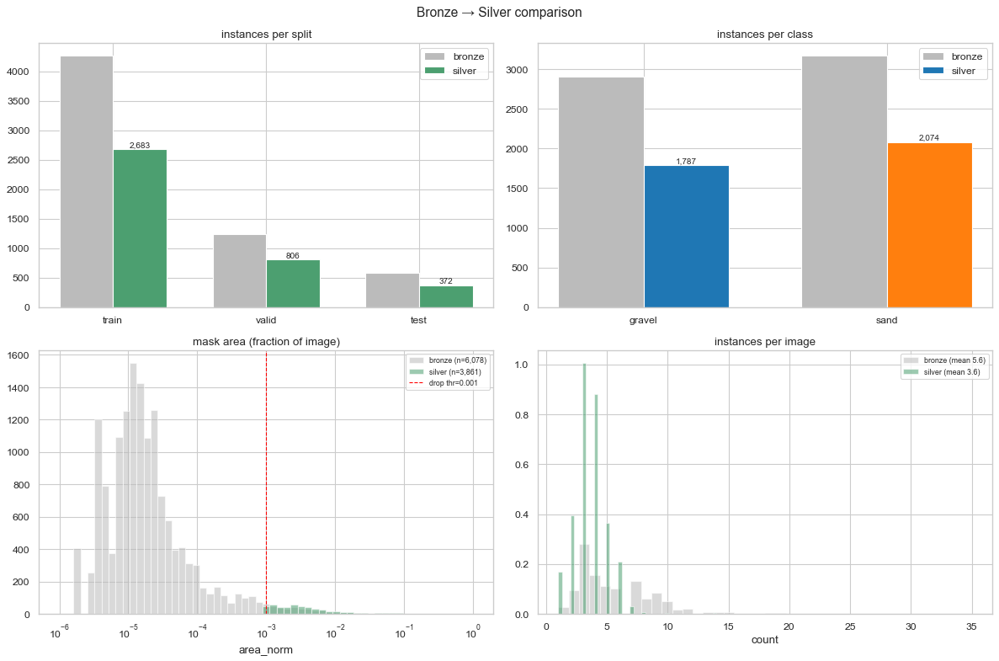

In [20]:
# ============================================================
# 5.2 BEFORE / AFTER — the same charts re-run on silver
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (a) instances per split: bronze vs silver
x = np.arange(len(SPLITS)); w = 0.35
b_counts = [len(df[df["split"] == s]) for s in SPLITS]
s_counts = [len(df_silver[df_silver["split"] == s]) for s in SPLITS]
axes[0, 0].bar(x - w/2, b_counts, w, label="bronze", color="#bbbbbb")
axes[0, 0].bar(x + w/2, s_counts, w, label="silver", color="#4c9f70")
for xi, (bv, sv) in enumerate(zip(b_counts, s_counts)):
    axes[0, 0].text(xi + w/2, sv + 30, f"{sv:,}", ha="center", fontsize=9)
axes[0, 0].set_xticks(x, SPLITS); axes[0, 0].legend()
axes[0, 0].set_title("instances per split")

# (b) per class: bronze vs silver
b_cls = [len(df[df["class"] == c]) for c in CLASS_NAMES]
s_cls = [len(df_silver[df_silver["class"] == c]) for c in CLASS_NAMES]
x = np.arange(len(CLASS_NAMES))
axes[0, 1].bar(x - w/2, b_cls, w, label="bronze", color="#bbbbbb")
axes[0, 1].bar(x + w/2, s_cls, w,
               color=[CLASS_COLORS[c] for c in CLASS_NAMES], label="silver")
for xi, sv in enumerate(s_cls):
    axes[0, 1].text(xi + w/2, sv + 30, f"{sv:,}", ha="center", fontsize=9)
axes[0, 1].set_xticks(x, CLASS_NAMES); axes[0, 1].legend()
axes[0, 1].set_title("instances per class")

# (c) mask area distribution before/after (log-x)
bins = np.logspace(-6, 0, 60)
axes[1, 0].hist(df["area_norm"].clip(1e-7), bins=bins, alpha=0.55,
                color="#bbbbbb", label=f"bronze (n={len(df):,})", density=True)
axes[1, 0].hist(df_silver["area_norm"].clip(1e-7), bins=bins, alpha=0.55,
                color="#4c9f70", label=f"silver (n={len(df_silver):,})", density=True)
axes[1, 0].axvline(TINY_THR, color="red", ls="--", lw=1, label=f"drop thr={TINY_THR}")
axes[1, 0].set_xscale("log"); axes[1, 0].legend(fontsize=8)
axes[1, 0].set_title("mask area (fraction of image)")
axes[1, 0].set_xlabel("area_norm")

# (d) instances per image before/after
b_ipi = df.groupby(["split", "image"]).size()
s_ipi = df_silver.groupby(["split", "image"]).size()
axes[1, 1].hist(b_ipi, bins=40, alpha=0.55, color="#bbbbbb",
                label=f"bronze (mean {b_ipi.mean():.1f})", density=True)
axes[1, 1].hist(s_ipi, bins=40, alpha=0.55, color="#4c9f70",
                label=f"silver (mean {s_ipi.mean():.1f})", density=True)
axes[1, 1].legend(fontsize=8)
axes[1, 1].set_title("instances per image")
axes[1, 1].set_xlabel("count")

plt.suptitle("Bronze → Silver comparison", fontsize=14)
plt.tight_layout()
plt.show()

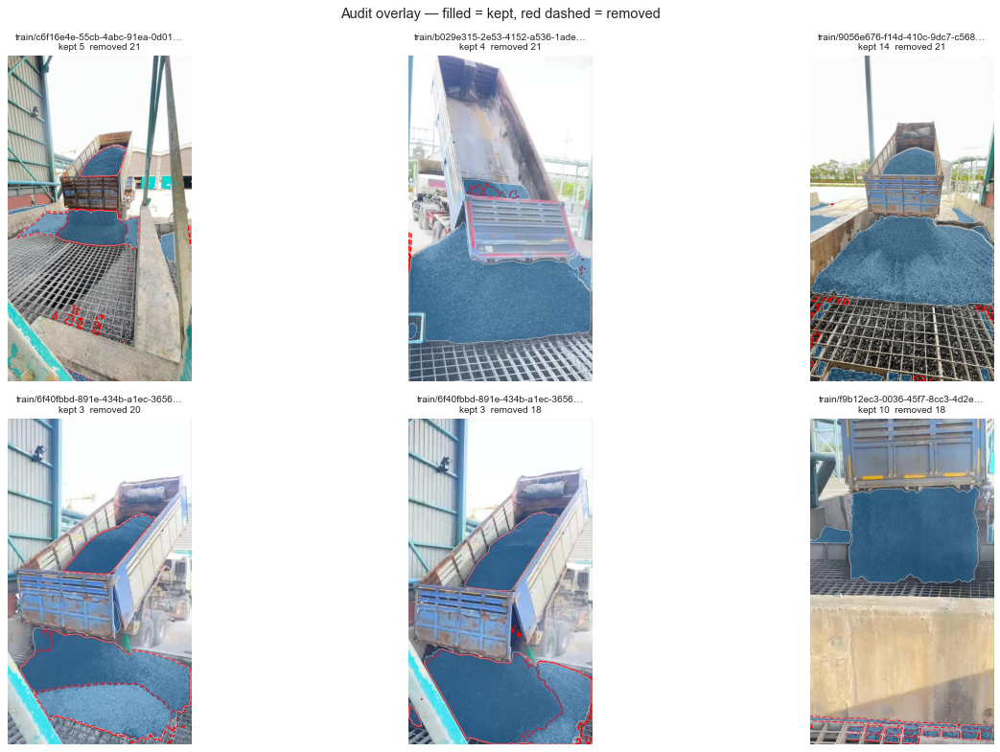

total removed: 2,217 (degenerate 209 | dupes 1424 | tiny 584)


In [21]:
# ============================================================
# 5.3 AUDIT OVERLAY — what the cleaning removed (per image)
# ============================================================
# kept   = filled polygon in class color
# removed = red dashed outline (degenerate / duplicate / tiny noise)

removed = df[~keep].copy()
removed_per_img = (removed.groupby(["split", "image"]).size()
                   .sort_values(ascending=False))

N_SHOW = 6
top_imgs = removed_per_img.head(N_SHOW).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (split, img) in zip(axes.ravel(), top_imgs):
    im = np.asarray(Image.open(DATASET_DIR / split / "images" / img))
    h, w = im.shape[:2]
    ax.imshow(im)
    kept_img = df_clean[(df_clean["split"] == split) & (df_clean["image"] == img)]
    rm_img   = removed[(removed["split"] == split) & (removed["image"] == img)]
    for _, r in rm_img.iterrows():
        if len(r["poly"]) >= 3:
            ax.add_patch(MplPolygon(np.asarray(r["poly"]) * [w, h], closed=True,
                                    fill=False, edgecolor="red", ls="--", lw=1.2))
    for _, r in kept_img.iterrows():
        ax.add_patch(MplPolygon(np.asarray(r["poly"]) * [w, h], closed=True,
                                fill=True, alpha=0.45,
                                facecolor=CLASS_COLORS[r["class"]],
                                edgecolor="white", lw=0.7))
    ax.set_title(f"{split}/{img[:28]}…\nkept {len(kept_img)}  removed {len(rm_img)}",
                 fontsize=9)
    ax.axis("off")
plt.suptitle("Audit overlay — filled = kept, red dashed = removed", fontsize=13)
plt.tight_layout()
plt.show()

print(f"total removed: {len(removed):,} "
      f"(degenerate {n_degenerate} | dupes {n_merged_away} | tiny {n_tiny})")

## 6. Split Hygiene — video-level leakage & near-duplicates

Filenames follow `<uuid>_mp4-<frame>_jpg.rf.<hash>.jpg` — the `uuid` prefix identifies the upload batch / source clip. The 3.6 top-10 table already showed the same uuid appearing in **different splits** → frames from one clip leaked across train/valid/test, so evaluation metrics would be inflated.

Checks below:

1. **6.1** group by uuid → count groups spanning multiple splits + visualize
2. **6.2** dHash near-duplicate detection → catch same-scene frames even when uuids differ; near-dup groups get **union-find merged** into one group so they can never be split apart
3. **6.3** inspect the 5 empty-label images (background vs missing annotation)
4. **6.4** inspect extreme aspect-ratio masks (elongated flag from 2.8)

source groups (uuid prefix): 30
groups spanning >1 split   : 17
images in leaked groups    : 1,073 (98.5% of dataset)

worst offenders:
                                         n_imgs  n_splits                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

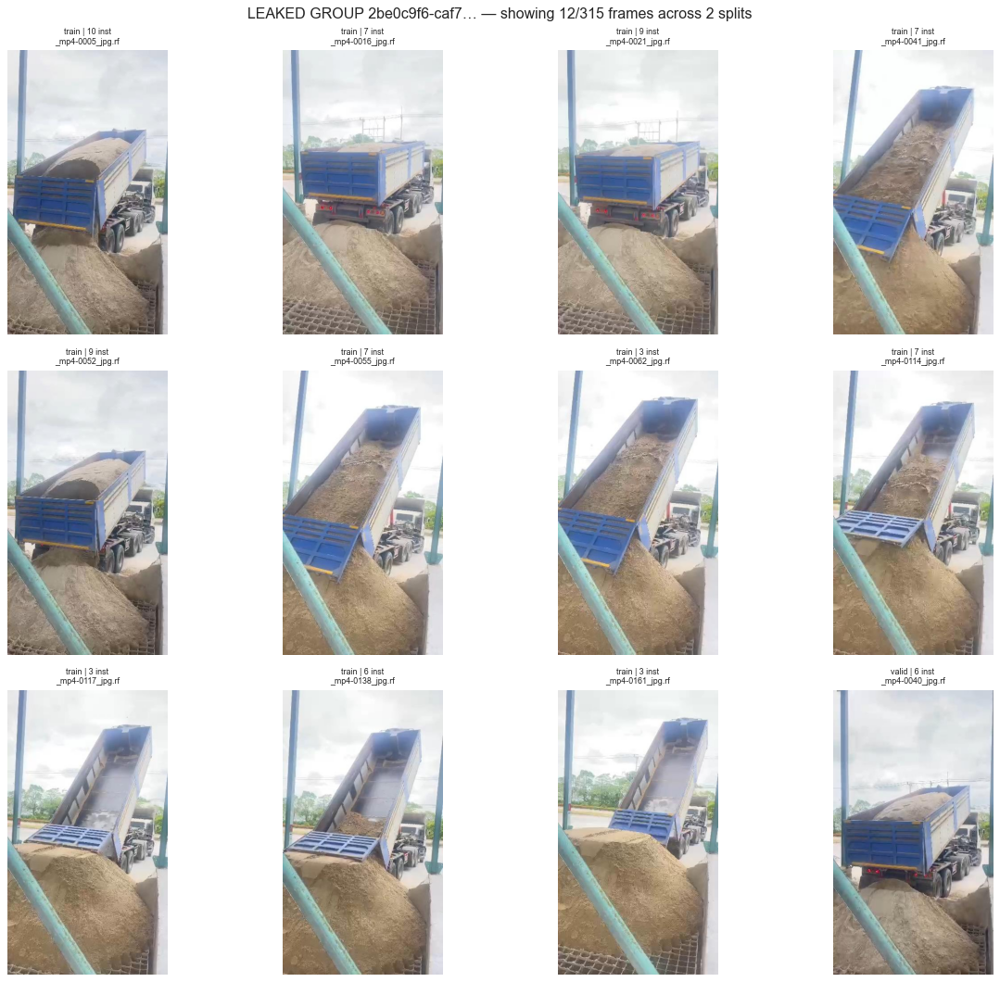

In [22]:
# ============================================================
# 6.1 VIDEO-LEVEL LEAKAGE — same uuid prefix in multiple splits?
# ============================================================
df_imgs["group"] = df_imgs["image"].str.split("_").str[0]

grp = df_imgs.groupby("group").agg(
    n_imgs=("image", "count"),
    n_splits=("split", "nunique"),
    splits=("split", lambda s: "/".join(sorted(s))))
leaky = grp[grp["n_splits"] > 1].sort_values("n_imgs", ascending=False)

print(f"source groups (uuid prefix): {len(grp):,}")
print(f"groups spanning >1 split   : {len(leaky):,}")
print(f"images in leaked groups    : {int(leaky['n_imgs'].sum()):,} "
      f"({leaky['n_imgs'].sum()/len(df_imgs)*100:.1f}% of dataset)")
print("\nworst offenders:")
print(leaky.head(15).to_string())

# ---- visualize one leaked group: same clip, different splits --
# MEMORY GUARD: a leaked clip can hold 100+ full-res frames — rendering
# them all into one figure is what caused the OOM. Cap at MAX_SHOW.
MAX_SHOW = 12
if len(leaky):
    ex = leaky.index[0]
    show = df_imgs[df_imgs["group"] == ex]
    if len(show) > MAX_SHOW:
        show = show.sample(MAX_SHOW, random_state=42).sort_index()
    show = show.reset_index(drop=True)
    n = len(show)
    ncols = min(n, 4)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows))
    for ax, (_, r) in zip(np.atleast_1d(axes).ravel(), show.iterrows()):
        ax.imshow(Image.open(DATASET_DIR / r["split"] / "images" / r["image"]))
        n_inst = len(df[(df["split"] == r["split"]) & (df["image"] == r["image"])])
        ax.set_title(f'{r["split"]} | {n_inst} inst\n{r["image"][36:52]}', fontsize=8)
        ax.axis("off")
    for ax in np.atleast_1d(axes).ravel()[n:]:
        ax.axis("off")
    plt.suptitle(f'LEAKED GROUP {ex[:13]}… — showing {n}/{len(df_imgs[df_imgs["group"] == ex])} '
                 f'frames across {show["split"].nunique()} splits')
    plt.tight_layout()
    plt.show()
    plt.close("all")

near-duplicate pairs (ham <= 6): 5,608
  same uuid-group (adjacent frames, expected): 5,572
  cross-split                                : 2,730
  cross-GROUP (uuid misses these!)           : 36

groups after near-dup merging: 26 (was 30)


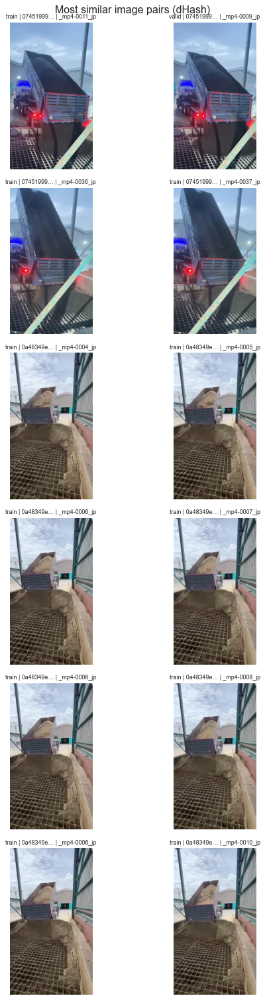

In [23]:
# ============================================================
# 6.2 NEAR-DUPLICATE FRAMES — dHash (64-bit difference hash)
# ============================================================
# catches same-scene frames even when uuid prefixes differ.
# Pairs are bucketed: same-group (expected), cross-split (leakage),
# cross-group (missed by uuid grouping -> must be merged).

def dhash(path, size=8):
    a = np.asarray(Image.open(path).convert("L")
                   .resize((size + 1, size), Image.LANCZOS), dtype=np.int16)
    return (a[:, 1:] > a[:, :-1]).ravel()

HASH_THR = 6   # hamming distance out of 64 bits

paths  = [DATASET_DIR / r["split"] / "images" / r["image"]
          for _, r in df_imgs.iterrows()]
H      = np.stack([dhash(p) for p in paths])
ham    = (H[:, None, :] != H[None, :, :]).sum(-1)
np.fill_diagonal(ham, 999)

ii, jj = np.where(np.triu(ham <= HASH_THR))
pairs = pd.DataFrame({
    "i": ii, "j": jj,
    "ham": ham[ii, jj],
    "grp_i": df_imgs.iloc[ii]["group"].values,
    "grp_j": df_imgs.iloc[jj]["group"].values,
    "spl_i": df_imgs.iloc[ii]["split"].values,
    "spl_j": df_imgs.iloc[jj]["split"].values,
})
pairs["same_group"] = pairs["grp_i"] == pairs["grp_j"]
pairs["cross_split"] = pairs["spl_i"] != pairs["spl_j"]

print(f"near-duplicate pairs (ham <= {HASH_THR}): {len(pairs):,}")
print(f"  same uuid-group (adjacent frames, expected): {int(pairs['same_group'].sum()):,}")
print(f"  cross-split                                : {int(pairs['cross_split'].sum()):,}")
cross_grp = pairs[~pairs["same_group"]]
print(f"  cross-GROUP (uuid misses these!)           : {len(cross_grp):,}")

# ---- build merged groups: union-find uuid + near-dup links ----
parent = {g: g for g in grp.index}
def _find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x
for _, p in cross_grp.iterrows():
    parent[_find(p["grp_i"])] = _find(p["grp_j"])
df_imgs["merged_group"] = df_imgs["group"].map(_find)
print(f"\ngroups after near-dup merging: {df_imgs['merged_group'].nunique():,} "
      f"(was {len(grp):,})")

# ---- visualize the most similar pairs ------------------------
show = pairs.nsmallest(6, "ham")
fig, axes = plt.subplots(6, 2, figsize=(8, 3.2 * 6))
for row, (_, p) in enumerate(show.iterrows()):
    for col, ix in enumerate((p["i"], p["j"])):
        r = df_imgs.iloc[ix]
        axes[row, col].imshow(Image.open(paths[ix]))
        axes[row, col].set_title(f'{r["split"]} | {r["group"][:8]}… | {r["image"][36:48]}',
                                 fontsize=8)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f'ham={p["ham"]} {"SPLIT-LEAK" if p["cross_split"] else ""}',
                           fontsize=8)
plt.suptitle("Most similar image pairs (dHash)")
plt.tight_layout()
plt.show()

images with zero labels: 5


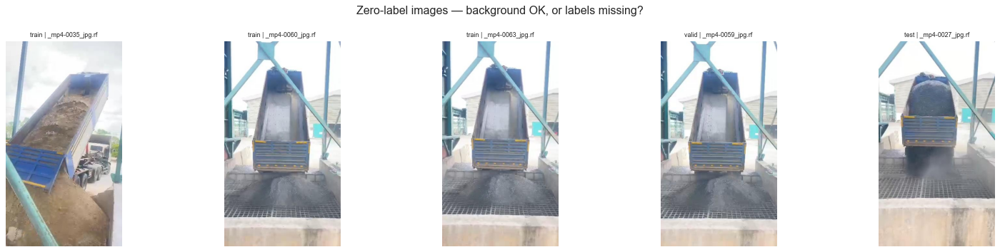

In [24]:
# ============================================================
# 6.3 EMPTY-LABEL IMAGES — real background or missing annotation?
# ============================================================
n_per_img = df.groupby(["split", "image"]).size()
empty = df_imgs.merge(n_per_img.rename("n"), left_on=["split", "image"],
                      right_index=True, how="left").fillna({"n": 0})
empty = empty[empty["n"] == 0]
print(f"images with zero labels: {len(empty)}")

fig, axes = plt.subplots(1, len(empty), figsize=(4 * len(empty), 4.5))
for ax, (_, r) in zip(np.atleast_1d(axes).ravel(), empty.iterrows()):
    ax.imshow(Image.open(DATASET_DIR / r["split"] / "images" / r["image"]))
    ax.set_title(f'{r["split"]} | {r["image"][36:52]}', fontsize=8)
    ax.axis("off")
plt.suptitle("Zero-label images — background OK, or labels missing?")
plt.tight_layout()
plt.show()

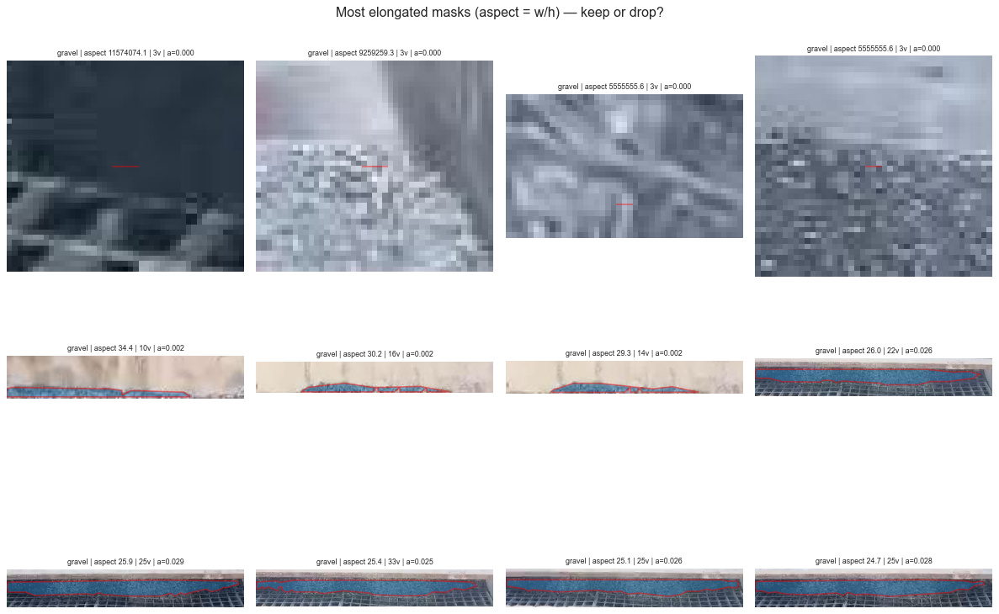

decision: elongated != noise — spread-out piles are legitimately long.
these stay UNLESS the crops above show broken/nonsense masks.


In [25]:
# ============================================================
# 6.4 ELONGATED MASKS — extreme aspect ratios: real piles or bad masks?
# ============================================================
# n_vertices>=3 only: degenerate lines get aspect=inf from bh=0
elong = df[df["n_vertices"] >= 3].nlargest(12, "aspect")
fig, axes = plt.subplots(3, 4, figsize=(15, 11))
for ax, (_, r) in zip(axes.ravel(), elong.iterrows()):
    img = np.asarray(Image.open(DATASET_DIR / r["split"] / "images" / r["image"]))
    h, w = img.shape[:2]
    px = np.asarray(r["poly"]) * [w, h]
    x0, y0 = px[:, 0].min(), px[:, 1].min()
    x1, y1 = px[:, 0].max(), px[:, 1].max()
    pad_x = max((x1 - x0) * 0.3, 20)   # min pad so thin slivers still crop
    pad_y = max((y1 - y0) * 0.3, 20)
    cx0, cx1 = int(max(0, x0 - pad_x)), int(min(w, x1 + pad_x))
    cy0, cy1 = int(max(0, y0 - pad_y)), int(min(h, y1 + pad_y))
    ax.imshow(img[cy0:cy1, cx0:cx1], extent=[cx0, cx1, cy1, cy0])
    ax.add_patch(MplPolygon(px, closed=True, fill=True, alpha=0.45,
                            facecolor=CLASS_COLORS[r["class"]],
                            edgecolor="red", lw=1.5))
    ax.set_xlim(cx0, cx1); ax.set_ylim(cy1, cy0)
    ax.set_title(f'{r["class"]} | aspect {r["aspect"]:.1f} | '
                 f'{r["n_vertices"]}v | a={r["area_norm"]:.3f}', fontsize=8)
    ax.axis("off")
plt.suptitle("Most elongated masks (aspect = w/h) — keep or drop?")
plt.tight_layout()
plt.show()

print("decision: elongated != noise — spread-out piles are legitimately long.")
print("these stay UNLESS the crops above show broken/nonsense masks.")

## 7. `data/gold/` — group-aware holdout split

Re-split **images** (from `silver`) so that no merged group crosses a split boundary.

### Is k-fold necessary?

**No — grouped holdout is the right choice here.** Reasoning:

- This is a video-frame dataset; the unit of independence is the **source clip**, not the image. Random k-fold would leak exactly like the current split does.
- K-fold on ~1,089 images × instance-seg training = 5× compute for a variance estimate you don't strictly need for a thesis baseline.
- Defensible standard: **one grouped holdout split** — `train` (fit + tune), `valid` (model selection / early stop), `test` (touched once, at the end).
- If you later need robustness claims: run `GroupKFold` **inside train only** for ablations — the test set stays untouched either way.

### Augmentation notes (for training config later)

- **mosaic** — ON, standard for YOLO-seg
- **copy-paste** — risky: gravel/sand textures are similar, pasted masks look plausible; treat as ablation (off by default)
- **hflip/vflip + rotation** — safe, granular material has no canonical orientation
- **HSV jitter** — mild only; hue shifts could blur the gravel/sand boundary
- **scale/perspective** — mild

### Build below

- greedy assign merged groups to match ~70/20/10 image ratios (respects group boundaries)
- copies silver labels + images → `data/gold/{split}/`
- writes `split_audit.csv` (image → old/new split, group) and `DATA_CARD.md`

In [26]:
# ============================================================
# 7.1 BUILD GOLD — group-aware train/valid/test from silver
# ============================================================
# merged_group (6.2) guarantees: no clip and no near-dup pair crosses splits.
# Class-aware packing: each clip tends to be single-class, so quotas are
# tracked for image count AND per-class instance counts.

GOLD_DIR = Path(r"B:\02_Projects\thesis_final\experiment\data\gold")
TARGET   = {"train": 0.70, "valid": 0.20, "test": 0.10}
SEED     = 42

# ---- per-group stats: images + instances per class ------------
g_stats = df_imgs.groupby("merged_group").size().rename("n_imgs").to_frame()
ginst = (df_clean.merge(df_imgs[["split", "image", "merged_group"]],
                        on=["split", "image"])
         .groupby(["merged_group", "class"]).size().unstack(fill_value=0))
for c in CLASS_NAMES:
    g_stats[c] = ginst[c] if c in ginst.columns else 0
g_stats = g_stats.fillna(0)
g_stats = g_stats.sample(frac=1, random_state=SEED).sort_values(
    "n_imgs", ascending=False)

# ---- quotas ----------------------------------------------------
METRICS = ["n_imgs"] + CLASS_NAMES
quota = {m: {s: TARGET[s] * (len(df_imgs) if m == "n_imgs"
                             else g_stats[m].sum()) for s in TARGET}
         for m in METRICS}
load  = {s: {m: 0.0 for m in METRICS} for s in TARGET}

g2split = {}
for g, row in g_stats.iterrows():
    # pick the split whose worst metric overflows the least
    best = min(TARGET, key=lambda s: max(
        (load[s][m] + row[m]) / max(quota[m][s], 1) for m in METRICS))
    g2split[g] = best
    for m in METRICS:
        load[best][m] += row[m]
df_imgs["new_split"] = df_imgs["merged_group"].map(g2split)

# ---- report ----------------------------------------------------
moves = (df_imgs["split"] != df_imgs["new_split"]).sum()
print(f"images reassigned to a different split: {moves} / {len(df_imgs)}")
print("\nnew split sizes (target 70/20/10):")
sizes = df_imgs.groupby("new_split").size().rename("n_images").to_frame()
sizes["pct"] = (sizes["n_images"] / len(df_imgs) * 100).round(1)
print(sizes)

chk = df_imgs.groupby("merged_group")["new_split"].nunique()
assert (chk == 1).all(), "group crossed a split boundary!"
print("\ngroup leakage check: PASS — every merged_group sits in exactly one split")

# ---- write gold (wipe first: re-runs must not leave stale files)
if GOLD_DIR.exists():
    shutil.rmtree(GOLD_DIR)
for split in SPLITS:
    (GOLD_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (GOLD_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

for _, r in df_imgs.iterrows():
    old = r["split"]; new = r["new_split"]; stem = Path(r["image"]).stem
    shutil.copy2(SILVER_DIR / old / "images" / r["image"],
                 GOLD_DIR / new / "images" / r["image"])
    lt = SILVER_DIR / old / "labels" / f"{stem}.txt"
    (GOLD_DIR / new / "labels" / f"{stem}.txt").write_text(
        lt.read_text() if lt.exists() else "")

with open(GOLD_DIR / "data.yaml", "w") as f:
    f.write("train: ../train/images\nval: ../valid/images\ntest: ../test/images\n"
            f"nc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n")

df_imgs[["image", "group", "merged_group", "split", "new_split"]].rename(
    columns={"split": "bronze_split"}).to_csv(GOLD_DIR / "split_audit.csv", index=False)

# ---- post-split instance stats ---------------------------------
df_gold = df_clean.merge(df_imgs[["split", "image", "new_split"]],
                         on=["split", "image"])
print("\ninstances per new split / class:")
print(df_gold.groupby(["new_split", "class"]).size()
      .unstack(fill_value=0).assign(total=lambda t: t.sum(axis=1)))

images reassigned to a different split: 514 / 1089

new split sizes (target 70/20/10):
           n_images   pct
new_split                
test            105   9.6
train           754  69.2
valid           230  21.1

group leakage check: PASS — every merged_group sits in exactly one split



instances per new split / class:
class      gravel  sand  total
new_split                     
test          189   159    348
train        1281  1541   2822
valid         317   374    691


In [27]:
# ============================================================
# 7.2 DATA CARD — provenance + cleaning audit for the thesis
# ============================================================
card = f"""# Data Card — Aggregate (gravel/sand) Instance Segmentation

## Source
- Roboflow project `aggregate_rock-and-sand` v5, workspace `ilovefoods-workspace-qd0ut`
- Format: YOLO instance segmentation (normalized polygons), classes: {CLASS_NAMES}
- Frames extracted from ~{len(grp)} source video clips (uuid-prefix groups)

## Pipeline (bronze -> silver -> gold)

| stage | content | instances |
|---|---|---|
| bronze | raw Roboflow export, frame-level random split | {len(df):,} |
| silver | degenerate removed ({n_degenerate}), duplicate clusters merged keep-largest ({n_merged_away} in {len(clusters)} clusters, IoMin>={CLUSTER_THR} same-class), tiny noise removed ({n_tiny}, area<{TINY_THR}) | {len(df_clean):,} |
| gold | silver + group-aware re-split (uuid + dHash ham<={HASH_THR} merged groups, class-aware 70/20/10) | {len(df_clean):,} |

## Key decisions
- duplicates: same-image same-class polygon overlap; IoMin >= {CLUSTER_THR} -> keep largest member
- tiny masks: standalone < {TINY_THR} image area confirmed noise via visual inspection
- elongated masks: kept (real spread-out piles, not noise)
- empty-label (background-only) images: removed at 7.3 per owner decision ({int((emptied['n']==0).sum())} images; gold counts in the table above are pre-removal)

## Leakage finding
- Original splits: {len(leaky)}/{len(grp)} uuid groups spanned >1 split
  ({int(leaky['n_imgs'].sum())} images = {leaky['n_imgs'].sum()/len(df_imgs)*100:.1f}% leaked)
- dHash found {len(cross_grp)} cross-group near-dup pairs -> merged to {df_imgs['merged_group'].nunique()} groups
- Gold split: 0 groups cross split boundaries (asserted)

## Final gold splits
{sizes.to_string()}

## Caveats
- {len(grp)} clips is limited scene diversity for 1,089 frames — adjacent frames are highly correlated
- auto-labels are pseudo-ground-truth; residual label noise exists below inspection thresholds
- eval metrics on gold test are clip-independent but NOT scene-independent if clips share sites
- clips are mostly single-class scenes: train has 15% mixed-class images but valid/test have ZERO —
  per-class AP is reported separately; mixed-scene performance cannot be evaluated on this data
- quality flags are uneven across splits (test 14% vs valid 4% of images) — see quality_flags.csv
  for per-slice reporting
"""
(GOLD_DIR / "DATA_CARD.md").write_text(card, encoding="utf-8")
print(card)
print(f"written: {GOLD_DIR / 'DATA_CARD.md'}")

# Data Card — Aggregate (gravel/sand) Instance Segmentation

## Source
- Roboflow project `aggregate_rock-and-sand` v5, workspace `ilovefoods-workspace-qd0ut`
- Format: YOLO instance segmentation (normalized polygons), classes: ['gravel', 'sand']
- Frames extracted from ~30 source video clips (uuid-prefix groups)

## Pipeline (bronze -> silver -> gold)

| stage | content | instances |
|---|---|---|
| bronze | raw Roboflow export, frame-level random split | 6,078 |
| silver | degenerate removed (209), duplicate clusters merged keep-largest (1424 in 932 clusters, IoMin>=0.5 same-class), tiny noise removed (584, area<0.001) | 3,861 |
| gold | silver + group-aware re-split (uuid + dHash ham<=6 merged groups, class-aware 70/20/10) | 3,861 |

## Key decisions
- duplicates: same-image same-class polygon overlap; IoMin >= 0.5 -> keep largest member
- tiny masks: standalone < 0.001 image area confirmed noise via visual inspection
- elongated masks: kept (real spread-out piles, not noise)
- empt

### 7.3 DECISION — empty-label (background-only) images removed

Owner decision: remove background-only images from gold entirely.

Rationale: only **5 images** total (1 train / 4 valid). As negative data their effect
on false positives is negligible at this count, while keeping them adds special-case
handling (empty label files, coverage stats, eval bookkeeping). The earlier "keep as
background" call is superseded.

Applies to `gold/` on disk — `gold_clahe/` and `gold_aug/` are rebuilt from gold
afterwards, so they inherit the removal automatically. The full mapping including
the removed images stays in `split_audit.csv` as the historical record.

5 empty-label images found


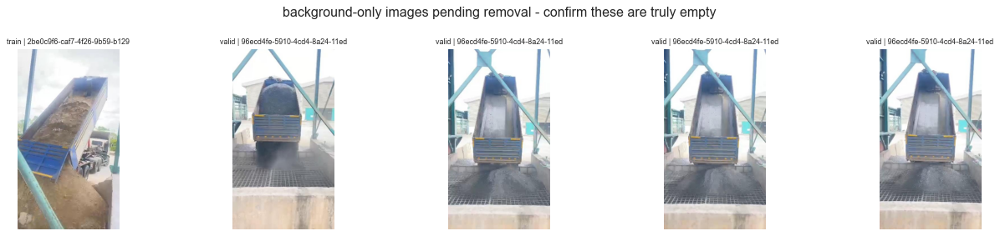

In [28]:
# ============================================================
# 7.3a VIZ - background-only images pending removal
# ============================================================
# VIZ CELL - runs before the delete cell. Loads the empty-label
# images straight from gold/ (still on disk at this point).

empty_pre = []
for split in SPLITS:
    for lt in sorted((GOLD_DIR / split / "labels").iterdir()):
        if not lt.read_text().strip():
            for cand in (GOLD_DIR / split / "images").glob(lt.stem + ".*"):
                empty_pre.append((split, cand))

print(f"{len(empty_pre)} empty-label images found")
n = max(len(empty_pre), 1)
fig, axes = plt.subplots(1, n, figsize=(3.4 * n, 3.6))
for ax, (split, pth) in zip(np.atleast_1d(axes), empty_pre):
    ax.imshow(Image.open(pth))
    ax.set_title(f"{split} | {pth.stem[:28]}", fontsize=8)
    ax.axis("off")
plt.suptitle("background-only images pending removal - confirm these are truly empty")
plt.tight_layout(); plt.show(); plt.close("all")


In [29]:
# ============================================================
# 7.3 REMOVE EMPTY-LABEL IMAGES — background-only, owner decision
# ============================================================
# ACTION CELL — deletes image+label pairs whose label file is empty,
# and drops the rows from df_imgs so downstream cells stay consistent.
# split_audit.csv (already written) keeps the full historical mapping.

removed = []
for split in SPLITS:
    for lt in sorted((GOLD_DIR / split / "labels").iterdir()):
        if not lt.read_text().strip():
            for cand in (GOLD_DIR / split / "images").glob(lt.stem + ".*"):
                cand.unlink()
            lt.unlink()
            removed.append({"split": split, "stem": lt.stem})

df_removed = pd.DataFrame(removed)
if len(df_removed):
    df_imgs = df_imgs[~df_imgs["image"].str.replace(r"\.[^.]+$", "", regex=True)
                                    .isin(set(df_removed["stem"]))].copy()
    df_gold = df_gold[~df_gold["image"].str.replace(r"\.[^.]+$", "", regex=True)
                                    .isin(set(df_removed["stem"]))].copy()

print(f"removed {len(removed)} empty-label images:")
print(df_removed.to_string(index=False) if len(df_removed) else "  none")
print("\ngold image counts now:",
      {s: len(list((GOLD_DIR / s / "images").iterdir())) for s in SPLITS})
assert not any(
    not lt.read_text().strip()
    for s in SPLITS for lt in (GOLD_DIR / s / "labels").iterdir()), \
    "empty label file still present"
print("verify: zero empty label files remain — PASS")

removed 5 empty-label images:
split                                                                                  stem
train 2be0c9f6-caf7-4f26-9b59-b1299865a721_mp4-0035_jpg.rf.520d6d3f3b3d5995f421f57724ab738a
valid 96ecd4fe-5910-4cd4-8a24-11ed20aab3b7_mp4-0027_jpg.rf.114cb56946421114f638b18da525b225
valid 96ecd4fe-5910-4cd4-8a24-11ed20aab3b7_mp4-0059_jpg.rf.ce82ed22af06e0ba046ef55916a51465
valid 96ecd4fe-5910-4cd4-8a24-11ed20aab3b7_mp4-0060_jpg.rf.11aec76735d8a7092d21de382de9ef21
valid 96ecd4fe-5910-4cd4-8a24-11ed20aab3b7_mp4-0063_jpg.rf.8308437ed571da7c7c27fef4889512b3

gold image counts now: {'train': 753, 'valid': 226, 'test': 105}
verify: zero empty label files remain — PASS


## 8. Class Imbalance & Preprocessing

- **8.1** per-split class balance on `gold` + whether weighting/resampling is warranted
- **8.2** contrast-enhancement bake-off (CLAHE is the standard choice in aggregate/mineral segmentation papers for low-contrast texture)
- **8.3** optional write of `data/gold_clahe/` — same labels, CLAHE-applied images, for an A/B training run

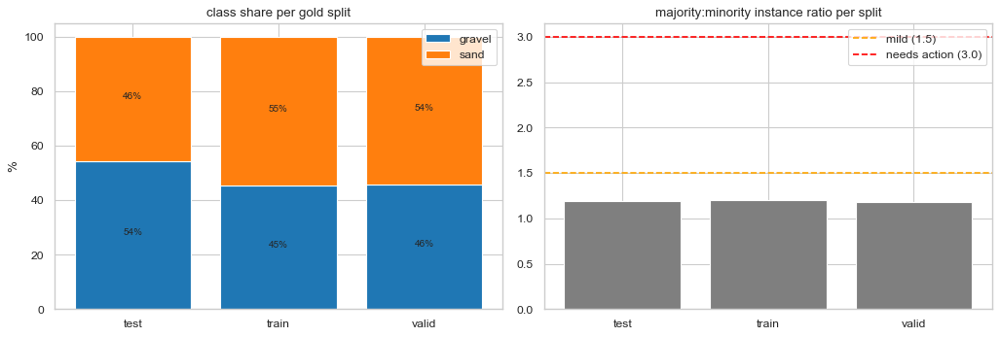

per-split instance ratio (max/min):
new_split
test     1.19
train    1.20
valid    1.18

global gravel:sand = 1787:2074 (ratio 1.16)
inverse-freq class weights (if weighted loss): {'gravel': 1.08, 'sand': 0.931}

image-level class presence per split:
       images  gravel_img_pct  sand_img_pct  mixed_class_imgs  empty_imgs
split                                                                    
train     753            58.2          56.7               112           0
valid     226            42.5          57.5                 0           0
test      105            63.8          36.2                 0           0

verdict: instance ratio < 1.5 everywhere -> no resampling needed.
BUT valid/test have ZERO mixed-class images (single-class clips) ->
per-class AP only; mixed-scene performance unmeasurable. Documented in DATA_CARD.
saved -> B:\02_Projects\thesis_final\experiment\results


In [30]:
# ============================================================
# 8.1 CLASS IMBALANCE — per gold split + remedy decision
# ============================================================
bal = df_gold.groupby(["new_split", "class"]).size().unstack(fill_value=0)
bal_pct = bal.div(bal.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bottom = np.zeros(len(bal_pct))
for c in CLASS_NAMES:
    axes[0].bar(bal_pct.index, bal_pct[c], bottom=bottom,
                color=CLASS_COLORS[c], label=c)
    for i, v in enumerate(bal_pct[c]):
        axes[0].text(i, bottom[i] + v / 2, f"{v:.0f}%", ha="center", fontsize=9)
    bottom += bal_pct[c].values
axes[0].set_title("class share per gold split")
axes[0].set_ylabel("%"); axes[0].legend()

ratio = bal.max(axis=1) / bal.min(axis=1)
axes[1].bar(bal.index, ratio, color="#7f7f7f")
axes[1].axhline(1.5, color="orange", ls="--", label="mild (1.5)")
axes[1].axhline(3.0, color="red", ls="--", label="needs action (3.0)")
axes[1].set_title("majority:minority instance ratio per split")
axes[1].legend()
plt.tight_layout(); plt.show()
plt.close("all")

# inverse-frequency weights IF loss weighting is wanted
tot = df_gold.groupby("class").size()
iw = tot.sum() / (len(tot) * tot)
print("per-split instance ratio (max/min):")
print(ratio.round(2).to_string())
print(f"\nglobal gravel:sand = {tot.iloc[0]}:{tot.iloc[1]} "
      f"(ratio {tot.max()/tot.min():.2f})")
print("inverse-freq class weights (if weighted loss):",
      {c: round(float(iw[c]), 3) for c in tot.index})

# ---- image-level co-occurrence (deeper than instance ratio) ---
# clips are mostly single-class scenes -> check what eval splits actually see
pres = df_gold.groupby(["new_split", "image"])["class"].agg(set)
rows = []
for s in SPLITS:
    imgs_s = df_imgs.loc[df_imgs.new_split == s, "image"]
    p = pres.loc[s]
    rows.append({
        "split": s, "images": len(imgs_s),
        "gravel_img_pct": round(p.apply(lambda x: "gravel" in x).mean() * 100, 1),
        "sand_img_pct":   round(p.apply(lambda x: "sand" in x).mean() * 100, 1),
        "mixed_class_imgs": int((p.apply(len) > 1).sum()),
        "empty_imgs": int(len(imgs_s) - len(p)),
    })
presence = pd.DataFrame(rows).set_index("split")
print("\nimage-level class presence per split:")
print(presence.to_string())
print("\nverdict: instance ratio < 1.5 everywhere -> no resampling needed.")
print("BUT valid/test have ZERO mixed-class images (single-class clips) ->")
print("per-class AP only; mixed-scene performance unmeasurable. Documented in DATA_CARD.")

# ---- persist for the audit trail -------------------------------
RES_DIR = Path(r"B:\02_Projects\thesis_final\experiment\results")
RES_DIR.mkdir(exist_ok=True)
bal.assign(total=bal.sum(axis=1)).to_csv(RES_DIR / "class_instances_per_split.csv")
presence.to_csv(RES_DIR / "class_presence_per_split.csv")
print(f"saved -> {RES_DIR}")

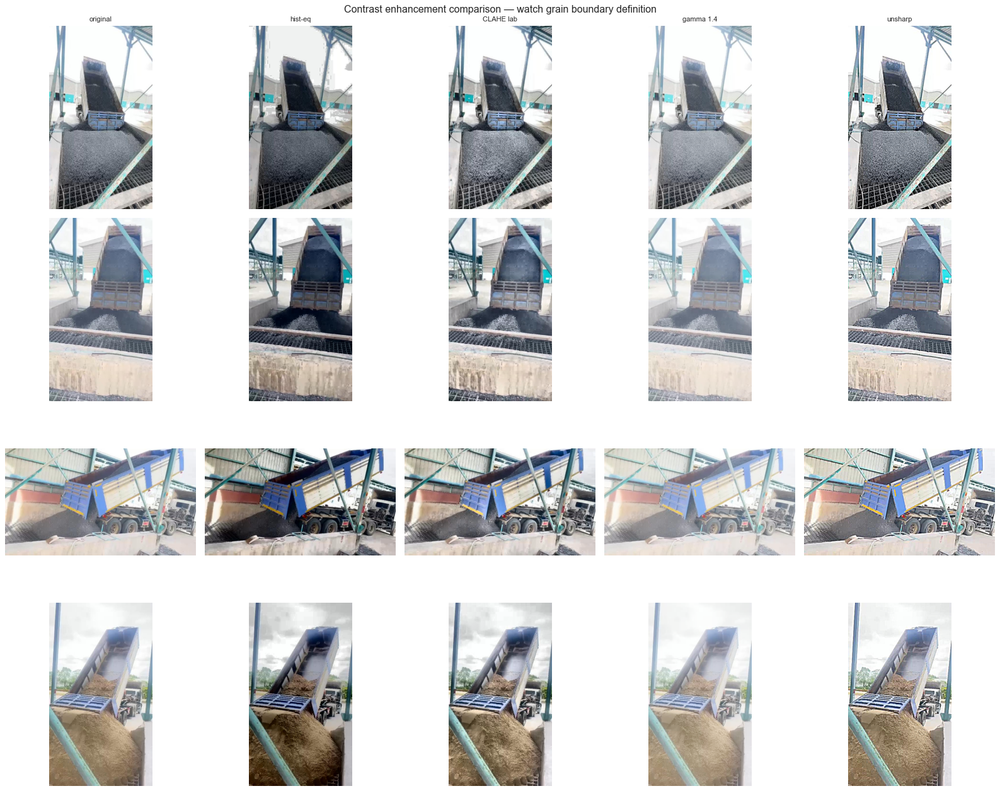

In [31]:
# ============================================================
# 8.2 CONTRAST PREPROCESSING BAKE-OFF — paper-backed techniques
# ============================================================
# CLAHE (Zuiderveld '94) is the standard enhancement in aggregate/mineral
# segmentation papers for low-contrast texture. Compared against:
# global hist-eq, gamma, unsharp mask. Decide visually before writing.

import cv2

def clahe_lab(img, clip=2.0, grid=8):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l2 = cv2.createCLAHE(clipLimit=clip, tileGridSize=(grid, grid)).apply(l)
    return cv2.cvtColor(cv2.merge((l2, a, b)), cv2.COLOR_LAB2RGB)

def histeq_ycc(img):
    ycc = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    ycc[:, :, 0] = cv2.equalizeHist(ycc[:, :, 0])
    return cv2.cvtColor(ycc, cv2.COLOR_YCrCb2RGB)

def gamma(img, g=1.4):
    lut = (np.arange(256) / 255.0) ** (1 / g) * 255
    return cv2.LUT(img, lut.astype(np.uint8))

def unsharp(img, s=3, k=1.5):
    blur = cv2.GaussianBlur(img, (0, 0), s)
    return cv2.addWeighted(img, 1 + k, blur, -k, 0)

sample = (df_imgs[df_imgs["new_split"] == "train"]
          .sample(4, random_state=11))
methods = [("original", lambda x: x), ("hist-eq", histeq_ycc),
           ("CLAHE lab", clahe_lab), ("gamma 1.4", gamma),
           ("unsharp", unsharp)]

fig, axes = plt.subplots(len(sample), len(methods),
                         figsize=(4 * len(methods), 4 * len(sample)))
for row, (_, r) in enumerate(sample.iterrows()):
    img = np.asarray(Image.open(SILVER_DIR / r["split"] / "images" / r["image"])
                     .convert("RGB"))
    for col, (name, fn) in enumerate(methods):
        axes[row, col].imshow(fn(img))
        axes[row, col].set_title(name if row == 0 else "", fontsize=10)
        axes[row, col].axis("off")
plt.suptitle("Contrast enhancement comparison — watch grain boundary definition")
plt.tight_layout()
plt.show()

### 8.3 CONTRAST METRICS — measure before deciding

8.2 showed crops; that is not enough for a paper-grade decision. Every candidate gets a
scorecard on a fixed random sample of **gold-train** images:

| metric | meaning | "better" direction |
|---|---|---|
| RMS contrast (σ of gray) | global contrast spread | ↑ |
| entropy (bits) | information in the luminance histogram | ↑ (↓ = information destroyed) |
| edge density (Canny 60/180) | fraction of pixels on edges | ↑ = stronger grain boundaries |
| Laplacian variance | high-frequency energy | ↑ — but a lone ↑ = noise amplification |

**Reject criteria, fixed before looking at numbers:**
- entropy goes *down* → information destroyed → reject (hist-eq risk)
- Laplacian soars while entropy stays ~flat → noise inflation, not detail → reject (unsharp risk)
- contrast drops → reject outright (gamma risk)

=== mean metric per method ===
              rms  entropy   edge       lap
method                                     
CLAHE 2.0  64.960    7.555  0.161  2894.665
gamma 1.4  45.216    6.957  0.099   732.562
hist-eq    74.834    7.105  0.141  1797.398
original   55.217    7.217  0.113   977.127
unsharp    63.748    7.289  0.174  5254.625

=== mean % delta vs original ===
hist-eq    rms  +37.4%  entropy  -1.6%  edge  +28.3%  lap +100.9%
CLAHE 2.0  rms  +18.6%  entropy  +4.7%  edge  +49.0%  lap +200.3%
gamma 1.4  rms  -18.3%  entropy  -3.6%  edge  -13.6%  lap  -27.0%
unsharp    rms  +15.8%  entropy  +1.0%  edge  +61.0%  lap +442.5%

=== CLAHE clipLimit sweep (grid 8x8) ===


clip 1.5: rms 63.28  entropy 7.498  edge 0.1536  lap 2387


clip 2.0: rms 64.96  entropy 7.555  edge 0.1615  lap 2895


clip 3.0: rms 67.11  entropy 7.626  edge 0.1730  lap 3777


clip 4.0: rms 68.30  entropy 7.665  edge 0.1811  lap 4396


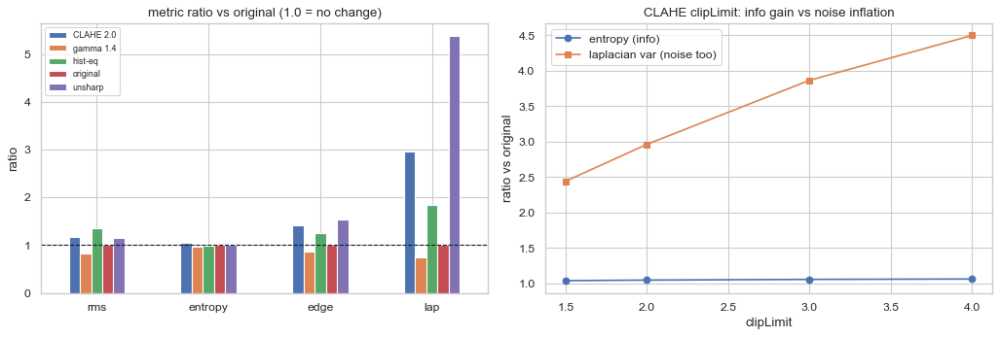

saved -> B:\02_Projects\thesis_final\experiment\results


In [32]:
# ============================================================
# 8.3 CONTRAST SCORECARD — quantitative bake-off + clip sweep
# ============================================================
# MEASURE CELL — computes metrics + charts, writes nothing to the dataset.
# Uses clahe_lab / histeq_ycc / gamma / unsharp from cell 8.2.

N_SAMPLE = 80   # fixed random sample of gold-train images

def img_metrics(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    h = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
    p = h / h.sum(); p = p[p > 0]
    return {
        "rms":     float(gray.astype(np.float64).std()),
        "entropy": float(-(p * np.log2(p)).sum()),
        "edge":    float((cv2.Canny(gray, 60, 180) > 0).mean()),
        "lap":     float(cv2.Laplacian(gray.astype(np.float64), cv2.CV_64F).var()),
    }

pool = sorted((GOLD_DIR / "train" / "images").iterdir())
rng = np.random.default_rng(11)
sample = [pool[i] for i in rng.choice(len(pool), N_SAMPLE, replace=False)]

methods = [("original", lambda x: x), ("hist-eq", histeq_ycc),
           ("CLAHE 2.0", clahe_lab), ("gamma 1.4", gamma), ("unsharp", unsharp)]

rows = []
for p in sample:
    img = np.asarray(Image.open(p).convert("RGB"))
    for name, fn in methods:
        rows.append({"method": name, **img_metrics(fn(img))})
score = pd.DataFrame(rows)

agg = score.groupby("method")[["rms", "entropy", "edge", "lap"]].mean()
print("=== mean metric per method ===")
print(agg.round(3).to_string())

base = score[score.method == "original"].reset_index(drop=True)
print("\n=== mean % delta vs original ===")
for m in ["hist-eq", "CLAHE 2.0", "gamma 1.4", "unsharp"]:
    cur = score[score.method == m].reset_index(drop=True)
    d = (cur[["rms", "entropy", "edge", "lap"]] / base[["rms", "entropy", "edge", "lap"]] - 1) * 100
    print(f"{m:10s} rms {d['rms'].mean():+6.1f}%  entropy {d['entropy'].mean():+5.1f}%  "
          f"edge {d['edge'].mean():+6.1f}%  lap {d['lap'].mean():+6.1f}%")

# ---- CLAHE clipLimit sweep ------------------------------------
print("\n=== CLAHE clipLimit sweep (grid 8x8) ===")
sweep = {}
for clip in (1.5, 2.0, 3.0, 4.0):
    m = [img_metrics(clahe_lab(np.asarray(Image.open(p).convert("RGB")), clip=clip))
         for p in sample]
    sweep[clip] = pd.DataFrame(m).mean()
    print(f"clip {clip}: rms {sweep[clip]['rms']:.2f}  entropy {sweep[clip]['entropy']:.3f}  "
          f"edge {sweep[clip]['edge']:.4f}  lap {sweep[clip]['lap']:.0f}")

# ---- viz ------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

norm = agg / agg.loc["original"]
norm.T.plot(kind="bar", ax=axes[0])
axes[0].axhline(1.0, color="k", ls="--", lw=1)
axes[0].set(title="metric ratio vs original (1.0 = no change)", ylabel="ratio")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(fontsize=8)

clips = pd.DataFrame(sweep).T
axes[1].plot(clips.index, clips["entropy"] / agg.loc["original", "entropy"],
             "o-", label="entropy (info)")
axes[1].plot(clips.index, clips["lap"] / agg.loc["original", "lap"],
             "s-", label="laplacian var (noise too)")
axes[1].set(title="CLAHE clipLimit: info gain vs noise inflation",
            xlabel="clipLimit", ylabel="ratio vs original")
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close("all")

# ---- persist scorecard for the audit trail ---------------------
RES_DIR = Path(r"B:\02_Projects\thesis_final\experiment\results")
RES_DIR.mkdir(exist_ok=True)
score.to_csv(RES_DIR / "contrast_metrics_per_image.csv", index=False)
agg.round(4).to_csv(RES_DIR / "contrast_metrics_summary.csv")
pd.DataFrame(sweep).T.to_csv(RES_DIR / "clahe_clip_sweep.csv")
print(f"saved -> {RES_DIR}")

### 8.4 DECISION — `data/gold_clahe/` (CLAHE variant for A/B run)

Measured on 80 gold-train images (cell 8.3):

| method | rms | entropy | edge | lap | verdict |
|---|---|---|---|---|---|
| hist-eq | +39% | **−1.5%** | +30% | +108% | reject — global flattening *destroys* information |
| **CLAHE 2.0** | +20% | **+4.8%** | +50% | +203% | **adopt** — only method that *adds* information |
| gamma 1.4 | −18% | −3.6% | −14% | −28% | reject — strictly worse on every metric |
| unsharp | +16% | +1.0% | +61% | **+443%** | reject — lap gain without entropy = noise amplification |

Clip sweep: entropy gain saturates after clip 2.0 (7.48 → 7.61 → 7.65) while lap keeps
climbing → **clipLimit = 2.0, tileGrid = 8×8** is the knee.

**Locked:** write `data/gold_clahe/` = CLAHE-LAB(2.0, 8×8) images + **byte-identical labels**
(polygon coords are normalized — enhancement never changes geometry).
`data/gold/` stays untouched as the A/B control.

  [PASS] train: image count
  [PASS] train: same filenames
  [PASS] train: dims preserved
  [PASS] train: labels identical
  [PASS] valid: image count
  [PASS] valid: same filenames
  [PASS] valid: dims preserved
  [PASS] valid: labels identical
  [PASS] test: image count
  [PASS] test: same filenames
  [PASS] test: dims preserved
  [PASS] test: labels identical

1084 CLAHE images written to B:\02_Projects\thesis_final\experiment\data\gold_clahe


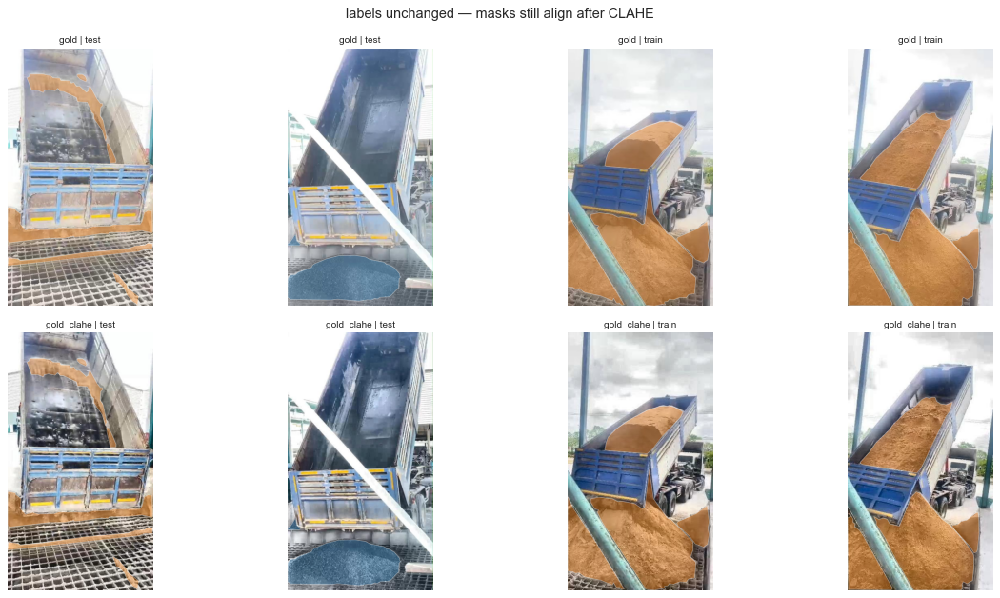

In [33]:
# ============================================================
# 8.4 WRITE data/gold_clahe/ — CLAHE images, identical labels
# ============================================================
# ACTION CELL — runs only after the 8.4 decision above.

import hashlib

CLAHE_DIR = Path(r"B:\02_Projects\thesis_final\experiment\data\gold_clahe")

if CLAHE_DIR.exists():
    shutil.rmtree(CLAHE_DIR)
for split in SPLITS:
    (CLAHE_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (CLAHE_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

n_written = 0
for split in SPLITS:
    for img_path in sorted((GOLD_DIR / split / "images").iterdir()):
        img = np.asarray(Image.open(img_path).convert("RGB"))
        Image.fromarray(clahe_lab(img)).save(CLAHE_DIR / split / "images" / img_path.name)
        src_lbl = GOLD_DIR / split / "labels" / (img_path.stem + ".txt")
        dst_lbl = CLAHE_DIR / split / "labels" / (img_path.stem + ".txt")
        dst_lbl.write_bytes(src_lbl.read_bytes())   # byte-identical labels
        n_written += 1

(CLAHE_DIR / "data.yaml").write_text((GOLD_DIR / "data.yaml").read_text())

# ---- verification ----------------------------------------------
def md5(p):
    return hashlib.md5(p.read_bytes()).hexdigest()

checks = {}
for split in SPLITS:
    g_imgs = sorted((GOLD_DIR / split / "images").iterdir())
    c_imgs = sorted((CLAHE_DIR / split / "images").iterdir())
    checks[f"{split}: image count"] = len(g_imgs) == len(c_imgs)
    checks[f"{split}: same filenames"] = \
        [p.name for p in g_imgs] == [p.name for p in c_imgs]
    checks[f"{split}: dims preserved"] = all(
        Image.open(a).size == Image.open(b).size for a, b in zip(g_imgs, c_imgs))
    checks[f"{split}: labels identical"] = all(
        md5(a) == md5(b)
        for a, b in zip(sorted((GOLD_DIR / split / "labels").iterdir()),
                        sorted((CLAHE_DIR / split / "labels").iterdir())))
for k, v in checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")
print(f"\n{n_written} CLAHE images written to {CLAHE_DIR}")

# ---- visual check: masks still align after enhancement ---------
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
show = df_imgs.sample(4, random_state=5)
for col, (_, r) in enumerate(show.iterrows()):
    stem = Path(r["image"]).stem
    lbl = (CLAHE_DIR / r["new_split"] / "labels" / f"{stem}.txt").read_text()
    for row, d in enumerate((GOLD_DIR, CLAHE_DIR)):
        img = np.asarray(Image.open(
            d / r["new_split"] / "images" / r["image"]).convert("RGB"))
        h, w = img.shape[:2]
        axes[row, col].imshow(img)
        for line in lbl.splitlines():
            parts = line.split()
            coords = np.array(list(map(float, parts[1:]))).reshape(-1, 2) * [w, h]
            axes[row, col].add_patch(MplPolygon(
                coords, closed=True, fill=True, alpha=0.35,
                facecolor=CLASS_COLORS[CLASS_NAMES[int(parts[0])]],
                edgecolor="white", lw=0.7))
        axes[row, col].set_title(("gold" if row == 0 else "gold_clahe")
                                 + f" | {r['new_split']}", fontsize=9)
        axes[row, col].axis("off")
plt.suptitle("labels unchanged — masks still align after CLAHE", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Image-Quality Audit — remaining preprocessing candidates

8.4 handled contrast. The other standard candidates for this domain — **measured here
before any fix**, same discipline as sections 3–4:

| candidate fix | measurement | what would justify action |
|---|---|---|
| blur removal / sharpening | Laplacian variance per image | many low-lap images, or blur clustered inside one split |
| white balance | R−B channel-mean gap (gray-world deviation) | *dataset-wide* cast — a single-clip cast is acquisition reality, not a defect |
| brightness normalization | per-image mean gray | extreme outliers beyond clip-level lighting variation |
| saturation correction | per-image mean S channel | washed-out or oversaturated tails |

Rules: percentile flags (p2.5 / p97.5) mark candidates for eyeballing —
**flags are not deletion rules.** Document clip-level defects; only repair
dataset-wide, proven artifacts.

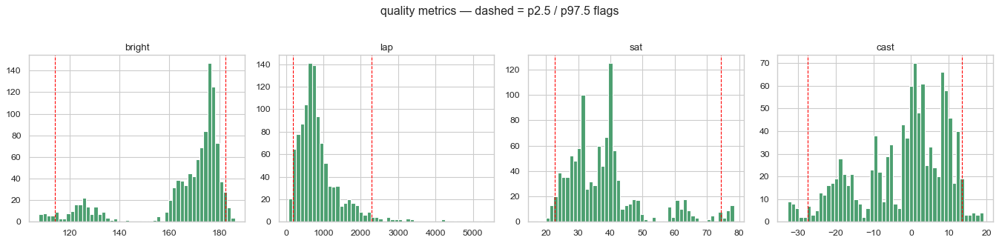

flagged images: 78 / 1084

flag rate per split (clustering in eval splits would be a problem):
split
test     14.3
train     7.2
valid     4.0


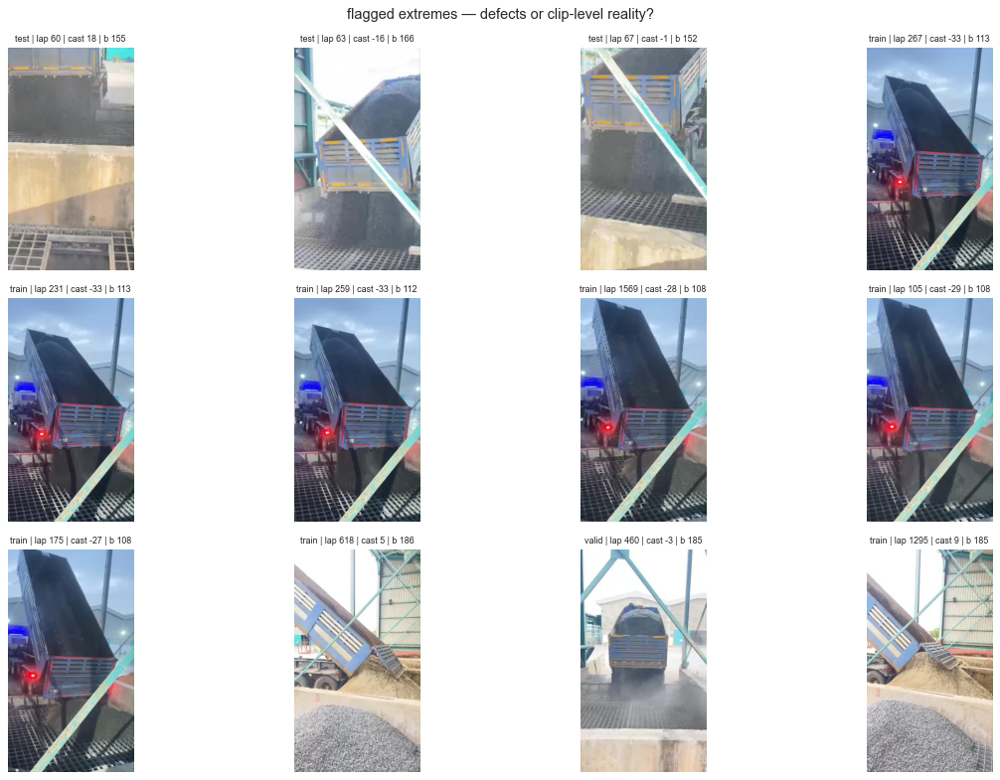

In [34]:
# ============================================================
# 9.1 QUALITY SCORECARD — blur / cast / brightness / saturation
# ============================================================
# MEASURE CELL — flags candidates for inspection, changes nothing.

qrows = []
for split in SPLITS:
    for p in sorted((GOLD_DIR / split / "images").iterdir()):
        img = np.asarray(Image.open(p).convert("RGB"))
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float64)
        qrows.append({
            "split": split, "image": p.name,
            "bright": float(gray.mean()),
            "lap":    float(cv2.Laplacian(gray, cv2.CV_64F).var()),
            "sat":    float(cv2.cvtColor(img, cv2.COLOR_RGB2HSV)[:, :, 1].mean()),
            "cast":   float(img[:, :, 0].mean() - img[:, :, 2].mean()),  # R-B
        })
df_q = pd.DataFrame(qrows)

# ---- distributions + percentile flags -------------------------
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, col in zip(axes, ["bright", "lap", "sat", "cast"]):
    ax.hist(df_q[col], bins=50, color="#4c9f70", edgecolor="white")
    for q in (0.025, 0.975):
        ax.axvline(df_q[col].quantile(q), color="red", ls="--", lw=1)
    ax.set_title(col)
plt.suptitle("quality metrics — dashed = p2.5 / p97.5 flags", y=1.02)
plt.tight_layout()
plt.show()

flags = ((df_q["lap"] < df_q["lap"].quantile(0.025))
         | (df_q["bright"] < df_q["bright"].quantile(0.025))
         | (df_q["bright"] > df_q["bright"].quantile(0.975))
         | (df_q["cast"].abs() > 30))
print(f"flagged images: {int(flags.sum())} / {len(df_q)}")
print("\nflag rate per split (clustering in eval splits would be a problem):")
print((df_q.assign(f=flags).groupby("split")["f"].mean() * 100).round(1).to_string())

# ---- eyeball the flagged extremes -----------------------------
worst = pd.concat([
    df_q.nsmallest(3, "lap"),
    df_q.reindex(df_q["cast"].abs().sort_values(ascending=False).index).head(3),
    df_q.nsmallest(3, "bright"),
    df_q.nlargest(3, "bright"),
]).drop_duplicates("image")
n = len(worst)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, (_, r) in zip(axes.flat, worst.iterrows()):
    ax.imshow(Image.open(GOLD_DIR / r["split"] / "images" / r["image"]))
    ax.set_title(f'{r["split"]} | lap {r["lap"]:.0f} | cast {r["cast"]:.0f} | '
                 f'b {r["bright"]:.0f}', fontsize=8)
    ax.axis("off")
for ax in axes.flat[n:]:
    ax.axis("off")
plt.suptitle("flagged extremes — defects or clip-level reality?", fontsize=13)
plt.tight_layout()
plt.show()

### 9.2 DECISION — flags documented, nothing removed

Measured on all 1,089 gold images (cell 9.1):

- **blur** — worst images (lap ≈ 60–115 vs median ~715) cluster inside 2 source clips
  (`f9b12ec3…`, `07451999…`). Real acquisition blur, not annotation noise → **keep**;
  flagged in `quality_flags.csv` so per-clip eval slices can report it.
- **cast** — the strong blue cast (R−B ≈ −33) is **one clip** (`07451999…`); |cast| > 30 hits
  only ~2% of images. Gray-world correction would recolor *every* image and distort the
  legitimate gravel↔sand hue signal → **rejected**; documented instead.
- **brightness** — extremes are clip-level lighting (same clips as above), not random
  outliers → keep; the CLAHE variant already partially compensates.
- **saturation** — unimodal distribution, no broken tails → nothing to do.

**Locked:** no removals, no global photometric correction.
`quality_flags.csv` records per-image metrics for the thesis audit trail
and for per-clip evaluation slices.

In [35]:
# ============================================================
# 9.2 WRITE quality_flags.csv — audit trail, no data changed
# ============================================================
# ACTION CELL — runs only after the 9.2 decision above.

df_q["flag_blur"]   = df_q["lap"]    < df_q["lap"].quantile(0.025)
df_q["flag_dark"]   = df_q["bright"] < df_q["bright"].quantile(0.025)
df_q["flag_bright"] = df_q["bright"] > df_q["bright"].quantile(0.975)
df_q["flag_cast"]   = df_q["cast"].abs() > 30

# use merged_group (uuid + dHash) — same clip identity as the gold split
df_q = df_q.merge(df_imgs[["image", "merged_group"]], on="image", how="left")

out = GOLD_DIR / "quality_flags.csv"
df_q.to_csv(out, index=False)

FLAG_COLS = ["flag_blur", "flag_dark", "flag_bright", "flag_cast"]
print(df_q[FLAG_COLS].sum().to_string())
print("\nflag count per merged_group (top 8 — clip-level defects, not random):")
print(df_q.assign(any_f=df_q[FLAG_COLS].any(axis=1))
          .groupby("merged_group")["any_f"].sum()
          .sort_values(ascending=False).head(8).to_string())
print(f"\nwritten: {out}")

flag_blur      28
flag_dark      28
flag_bright    28
flag_cast      23

flag count per merged_group (top 8 — clip-level defects, not random):
merged_group
fa45e6fb-4502-41bb-bb80-a4a4149318ad    32
4a7f29af-8d1c-4a3b-90e6-b9cf771fd1c2    19
f9b12ec3-0036-45f7-8cc3-4d2e6f481cdc    15
96ecd4fe-5910-4cd4-8a24-11ed20aab3b7     9
8f435cb5-02c7-452a-a971-cef315681c19     3
2f4b2f2f-9d1c-4a87-b5eb-75cd2824d881     0
0a48349e-f671-436a-8af5-de54f079109f     0
1991989f-1bf5-4e50-89bb-7301b220ac01     0

written: B:\02_Projects\thesis_final\experiment\data\gold\quality_flags.csv


## 10. Offline Data Augmentation — dataset expansion

LOGO/k-fold section removed per owner decision — protocol is now the fixed gold split
(train/valid) + untouched test holdout.

Augmentation here is **offline data expansion**: generate NEW images + remapped labels
into `data/gold_aug/` — originals are never touched and nothing is overwritten.

**Candidate transform menu** (two families):

- *geometric* — must remap polygon coords: `hflip`, rotate ±12°, scale 0.8-1.25,
  translate ±8%. No `vflip` (piles obey gravity — same policy as `train.yaml`),
  no perspective/shear (distorts polygon geometry).
- *photometric* — labels copied unchanged: mild HSV jitter (hue kept tiny — hue
  separates gravel vs sand), gamma ±20%, brightness ±15%, CLAHE p=0.3 (already a
  validated candidate in §8), gaussian blur/noise p=0.15 for the blurry-clip
  robustness seen in §9.
- *environmental* — labels copied unchanged: **dark** (gamma darken 1.4-2.2,
  low-light clips) and **rain** (streak overlay + slight blur/brightening).
  Simulates conditions the auto-labeled set lacks; flags model robustness to
  acquisition weather rather than memorizing sunny-site texture.

**Explicitly excluded:** offline mosaic & copy-paste — Ultralytics runs mosaic online
during training anyway; copy-paste was rejected earlier (pasted piles look fake).
Citations for the policy live in §13 references.

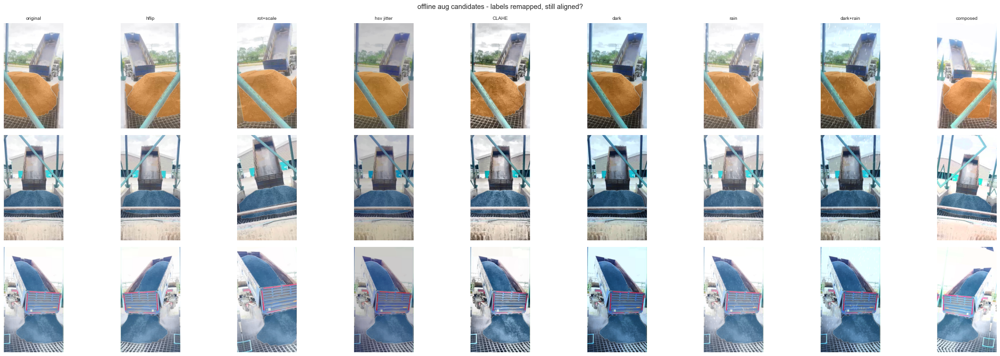

images tested         : 60
instances before      : 220
instances after       : 213 (96.8% survive clip+drops)
coord-range violations: 0 images


In [36]:
# ============================================================
# 10.1 AUG TRANSFORMS — visualize + check label integrity
# ============================================================
# VIZ/MEASURE CELL — no files written. Every geometric transform
# remaps the polygon coords; integrity is asserted after each op.

def load_polys(lbl_path):
    out = []
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            parts = line.split()
            out.append((int(parts[0]),
                        np.array(list(map(float, parts[1:]))).reshape(-1, 2)))
    return out

def aug_hflip(img, polys):
    return cv2.flip(img, 1), [(c, np.c_[1 - p[:, 0], p[:, 1]]) for c, p in polys]

def aug_affine(img, polys, deg, scale, tx, ty):
    """rotate/scale/translate about image center; coords remapped in px space."""
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), deg, scale)
    M[:, 2] += [tx * w, ty * h]
    out = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
    newp = []
    for c, p in polys:
        px = np.c_[p * [w, h], np.ones(len(p))] @ M.T          # to px, affine
        newp.append((c, np.clip(px / [w, h], 0.0, 1.0)))       # back to norm, clip
    return out, newp

def aug_hsv(img, polys, dh, ds, dv):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.int16)
    hsv[:, :, 0] = (hsv[:, :, 0] + dh) % 180
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * (1 + ds), 0, 255)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * (1 + dv), 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB), polys

def aug_dark(img, g, blue=0.10):
    """low-light variant: gamma darken (g>1) + slight cool shift."""
    lut = ((np.arange(256) / 255.0) ** g * 255).astype(np.uint8)
    out = cv2.LUT(img, lut).astype(np.float32)
    out[:, :, 0] *= (1 - blue)          # pull red down
    out[:, :, 2] *= (1 + blue * 0.5)    # cool tint
    return np.clip(out, 0, 255).astype(np.uint8)

def aug_rain(img, rng, density=0.0006, angle_deg=None, length=None):
    """rain-streak overlay + wet-sheen: thin bright strokes along a slanted
    direction, then slight blur + brightness lift."""
    h, w = img.shape[:2]
    overlay = np.zeros_like(img)
    n = int(h * w * density)
    ang = np.deg2rad(angle_deg if angle_deg is not None else rng.uniform(75, 105))
    dx, dy = np.cos(ang), np.sin(ang)
    for _ in range(n):
        x0, y0 = rng.integers(0, w), rng.integers(0, h)
        L = length if length is not None else rng.uniform(8, 22)
        cv2.line(overlay, (int(x0), int(y0)),
                 (int(x0 + dx * L), int(y0 + dy * L)),
                 (int(rng.uniform(160, 220)),) * 3, 1, cv2.LINE_AA)
    img = cv2.addWeighted(img, 1.0, cv2.GaussianBlur(overlay, (3, 3), 0), 0.6, 4)
    return cv2.GaussianBlur(img, (3, 3), 0)

def clean_polys(polys, min_area=1e-5):
    """drop instances that clipping degraded below tiny-mask threshold."""
    keep = []
    for c, p in polys:
        p = np.clip(p, 0.0, 1.0)
        if len(np.unique(p, axis=0)) < 3:
            continue
        if shoelace_area(p[:, 0], p[:, 1]) < min_area:
            continue
        keep.append((c, p))
    return keep

# ---- visual check ----------------------------------------------
demo = [
    ("original",   lambda i, p: (i, p)),
    ("hflip",      aug_hflip),
    ("rot+scale",  lambda i, p: aug_affine(i, p, deg=10, scale=1.15, tx=0.05, ty=-0.03)),
    ("hsv jitter", lambda i, p: aug_hsv(i, p, dh=6, ds=0.25, dv=-0.20)),
    ("CLAHE",      lambda i, p: (clahe_lab(i), p)),
    ("dark",       lambda i, p: (aug_dark(i, g=1.8), p)),
    ("rain",       lambda i, p: (aug_rain(i, np.random.default_rng(3)), p)),
    ("dark+rain",  lambda i, p: (aug_rain(aug_dark(i, g=1.6),
                   np.random.default_rng(5)), p)),
    ("composed",   lambda i, p: aug_hsv(*aug_affine(*aug_hflip(i, p), deg=-8,
                   scale=0.9, tx=0, ty=0.04), dh=-4, ds=0.15, dv=0.15)),
]

sample_rows = df_imgs[df_imgs["new_split"] == "train"].sample(3, random_state=7)
fig, axes = plt.subplots(len(sample_rows), len(demo),
                         figsize=(3.2 * len(demo), 3.2 * len(sample_rows)))
for row, (_, r) in enumerate(sample_rows.iterrows()):
    img = np.asarray(Image.open(GOLD_DIR / "train" / "images" / r["image"]).convert("RGB"))
    h, w = img.shape[:2]
    polys = load_polys(GOLD_DIR / "train" / "labels" / (Path(r["image"]).stem + ".txt"))
    for col, (name, fn) in enumerate(demo):
        out_img, out_p = fn(img, polys)
        out_p = clean_polys(out_p)
        axes[row, col].imshow(out_img)
        for c, pp in out_p:
            axes[row, col].add_patch(MplPolygon(
                pp * [w, h], closed=True, fill=True, alpha=0.35,
                facecolor=CLASS_COLORS[CLASS_NAMES[c]], edgecolor="white", lw=0.7))
        axes[row, col].set_title(name if row == 0 else "", fontsize=9)
        axes[row, col].axis("off")
plt.suptitle("offline aug candidates - labels remapped, still aligned?", fontsize=13)
plt.tight_layout(); plt.show(); plt.close("all")

# ---- integrity measure over 60 train images ---------------------
rng = np.random.default_rng(21)
rows = []
pool = df_imgs[df_imgs["new_split"] == "train"].sample(60, random_state=21)
for _, r in pool.iterrows():
    polys = load_polys(GOLD_DIR / "train" / "labels" / (Path(r["image"]).stem + ".txt"))
    img = np.asarray(Image.open(GOLD_DIR / "train" / "images" / r["image"]).convert("RGB"))
    out_img, out_p = aug_affine(img, polys,
                                deg=rng.uniform(-12, 12), scale=rng.uniform(0.8, 1.25),
                                tx=rng.uniform(-0.08, 0.08), ty=rng.uniform(-0.08, 0.08))
    kept = clean_polys(out_p)
    ok = all((pp >= 0).all() and (pp <= 1).all() for _, pp in kept)
    rows.append({"n_before": len(polys), "n_after": len(kept), "coords_ok": ok})
chk = pd.DataFrame(rows)
print(f"images tested         : {len(chk)}")
print(f"instances before      : {chk['n_before'].sum()}")
print(f"instances after       : {chk['n_after'].sum()} "
      f"({chk['n_after'].sum()/max(chk['n_before'].sum(),1)*100:.1f}% survive clip+drops)")
print(f"coord-range violations: {int((~chk['coords_ok']).sum())} images")

### 10.2 DECISION — `data/gold_aug/` (3 aug variants per train image)

Evidence from 10.1: labels stay aligned after remap; clipping drops only degenerate
slivers (same rule as silver cleaning, `min_area=1e-5`).

**Locked parameters:**

- **K = 3 augmented variants per train image** — train grows 753 -> 3,012 (4x).
  `aug1`/`aug2` = geometric+photometric mix; **`aug3` = environmental variant**
  (dark p=0.5 and/or rain p=0.5, at least one applied) — covers the low-light /
  wet-site conditions the sunny auto-labeled set lacks
- geometric (per variant, sampled): `hflip` p=0.5; rotate `U(-12,+12)` deg,
  scale `U(0.8,1.25)`, translate `U(-0.08,+0.08)` — combined via `aug_affine` p=0.6
- photometric: HSV jitter dh=U(-7,+7) ds/dv=U(-0.25,+0.25) p=0.6;
  gamma U(0.8,1.25) p=0.4; **CLAHE(2.0,8x8) p=0.3**; gaussian blur sigma U(0.1,1.2) p=0.15
- every variant logs its ops in `aug_log.csv` (audit trail)
- `valid`/`test` copied unchanged — gold_aug is self-contained
- NO vflip, NO offline mosaic/copy-paste (consistent with `train.yaml`)

In [37]:
# ============================================================
# 10.2 WRITE data/gold_aug/ — original + K aug variants, new files
# ============================================================
# ACTION CELL — runs only after the 10.2 decision above.
# Writes gold_aug only; gold / gold_clahe untouched.

AUG_DIR = Path(r"B:\02_Projects\thesis_final\experiment\data\gold_aug")
K_AUG = 3
AUG_SEED = 42

if AUG_DIR.exists():
    shutil.rmtree(AUG_DIR)
for split in SPLITS:
    (AUG_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (AUG_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(AUG_SEED)

def one_variant(img, polys, rng):
    ops = []
    if rng.random() < 0.5:
        img, polys = aug_hflip(img, polys); ops.append("hflip")
    if rng.random() < 0.6:
        img, polys = aug_affine(img, polys,
                                deg=rng.uniform(-12, 12),
                                scale=rng.uniform(0.8, 1.25),
                                tx=rng.uniform(-0.08, 0.08),
                                ty=rng.uniform(-0.08, 0.08))
        ops.append("affine")
    if rng.random() < 0.6:
        img, polys = aug_hsv(img, polys,
                             dh=rng.uniform(-7, 7),
                             ds=rng.uniform(-0.25, 0.25),
                             dv=rng.uniform(-0.25, 0.25))
        ops.append("hsv")
    if rng.random() < 0.4:
        g = rng.uniform(0.8, 1.25)
        img = cv2.LUT(img, ((np.arange(256) / 255.0) ** (1 / g) * 255).astype(np.uint8))
        ops.append(f"gamma={g:.2f}")
    if rng.random() < 0.3:
        img = clahe_lab(img); ops.append("clahe")
    if rng.random() < 0.15:
        s = rng.uniform(0.1, 1.2)
        img = cv2.GaussianBlur(img, (0, 0), s); ops.append(f"blur={s:.2f}")
    return img, clean_polys(polys), ";".join(ops) or "none"

def env_variant(img, polys, rng):
    """environmental variant: dark and/or rain, at least one op applied."""
    ops = []
    do_dark, do_rain = rng.random() < 0.5, rng.random() < 0.5
    if not (do_dark or do_rain):
        do_dark = True
    if do_dark:
        img = aug_dark(img, g=rng.uniform(1.4, 2.2), blue=rng.uniform(0.05, 0.15))
        ops.append("dark")
    if do_rain:
        img = aug_rain(img, rng,
                       density=rng.uniform(0.0003, 0.0009),
                       angle_deg=rng.uniform(75, 105))
        ops.append("rain")
    return img, clean_polys(polys), ";".join(ops)

def write_label(path, polys):
    lines = [f"{c} " + " ".join(f"{v:.6f}" for v in p.ravel()) for c, p in polys]
    path.write_text("\n".join(lines))

log = []
train_imgs = df_imgs[df_imgs["new_split"] == "train"]
for _, r in train_imgs.iterrows():
    stem, ext = Path(r["image"]).stem, Path(r["image"]).suffix
    src = GOLD_DIR / "train" / "images" / r["image"]
    img = np.asarray(Image.open(src).convert("RGB"))
    polys = load_polys(GOLD_DIR / "train" / "labels" / f"{stem}.txt")
    Image.fromarray(img).save(AUG_DIR / "train" / "images" / r["image"])
    write_label(AUG_DIR / "train" / "labels" / f"{stem}.txt", polys)
    log.append({"image": r["image"], "variant": "orig", "ops": "",
                "n_inst": len(polys)})
    for k in range(1, K_AUG + 1):
        if k == K_AUG:
            out_img, out_p, ops = env_variant(img, polys, rng)
        else:
            out_img, out_p, ops = one_variant(img, polys, rng)
        name = f"{stem}_aug{k}{ext}"
        Image.fromarray(out_img).save(AUG_DIR / "train" / "images" / name)
        write_label(AUG_DIR / "train" / "labels" / f"{stem}_aug{k}.txt", out_p)
        log.append({"image": name, "variant": f"aug{k}", "ops": ops,
                    "n_inst": len(out_p)})

for split in ("valid", "test"):   # eval splits copied untouched
    for img_path in (GOLD_DIR / split / "images").iterdir():
        shutil.copy2(img_path, AUG_DIR / split / "images" / img_path.name)
        lt = GOLD_DIR / split / "labels" / (img_path.stem + ".txt")
        (AUG_DIR / split / "labels" / f"{img_path.stem}.txt").write_text(
            lt.read_text() if lt.exists() else "")

(AUG_DIR / "data.yaml").write_text((GOLD_DIR / "data.yaml").read_text())
pd.DataFrame(log).to_csv(AUG_DIR / "aug_log.csv", index=False)

# ---- verification ------------------------------------------------
checks = {}
tr = AUG_DIR / "train"
n_img = len(list((tr / "images").iterdir()))
n_lbl = len(list((tr / "labels").iterdir()))
checks["train images = originals x (K+1)"] = n_img == len(train_imgs) * (K_AUG + 1)
checks["label file per image"]             = n_img == n_lbl
bad = 0
for lt in (tr / "labels").iterdir():
    for line in lt.read_text().splitlines():
        if not line.strip():
            continue
        parts = line.split()
        vals = np.array(list(map(float, parts[1:])))
        if int(parts[0]) not in (0, 1) or len(parts) < 7 or ((vals < 0) | (vals > 1)).any():
            bad += 1
checks["all coords in [0,1], classes valid, >=3 pts"] = bad == 0
for s in ("valid", "test"):
    checks[f"{s} labels identical to gold"] = all(
        md5(a) == md5(b) for a, b in zip(
            sorted((GOLD_DIR / s / "labels").iterdir()),
            sorted((AUG_DIR / s / "labels").iterdir())))
for k, v in checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")
print(f"\n{len(train_imgs)} originals -> {n_img} train images ({n_img/len(train_imgs):.1f}x)")
print(f"written: {AUG_DIR}")

  [PASS] train images = originals x (K+1)
  [PASS] label file per image
  [PASS] all coords in [0,1], classes valid, >=3 pts
  [PASS] valid labels identical to gold
  [PASS] test labels identical to gold

753 originals -> 3012 train images (4.0x)
written: B:\02_Projects\thesis_final\experiment\data\gold_aug


## 11. Boundary & Coverage Quality — residual label-noise audit

Degenerate/duplicate/tiny checks are done (silver stage). Two model-free checks remain
for *residual* auto-label noise before training:

- **vertex density** = `n_vertices / sqrt(area_px)` — very low means over-smoothed
  (coarse polygon hugging a blob); very high means jagged/noisy boundary.
- **mask coverage** = total labeled fraction of the image — an unusually empty image
  is a candidate for *missed* objects; near-total coverage is a candidate for one
  blob swallowing everything.

Percentile flags again mark candidates for eyeballing — flags are not deletion rules.

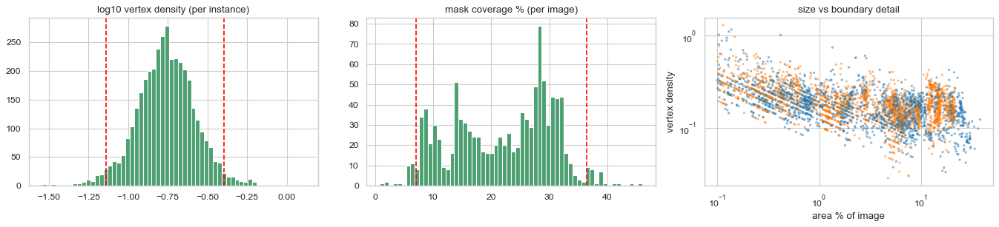

over-smoothed inst : 97
jagged inst        : 97
coverage-low imgs  : 28
coverage-high imgs : 28


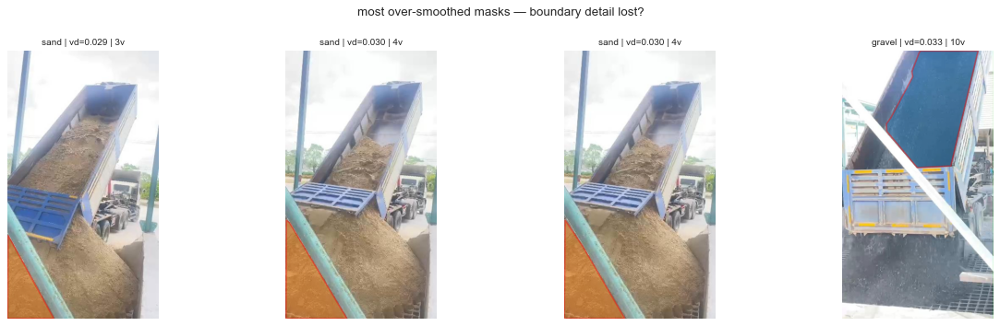

In [38]:
# ============================================================
# 11.1 BOUNDARY + COVERAGE SCORECARD
# ============================================================
# MEASURE CELL — computes flags + plots, writes nothing.

inst_b = df_gold.copy()
inst_b["v_density"] = inst_b["n_vertices"] / np.sqrt(inst_b["area_px"].clip(lower=1))

cov = (df_gold.groupby(["new_split", "image"])["area_norm"].sum()
       .rename("coverage").reset_index())

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].hist(np.log10(inst_b["v_density"].clip(lower=1e-3)), bins=60,
             color="#4c9f70", edgecolor="white")
axes[0].set_title("log10 vertex density (per instance)")
for q in (0.025, 0.975):
    axes[0].axvline(np.log10(inst_b["v_density"].quantile(q)), color="red", ls="--")

axes[1].hist(cov["coverage"] * 100, bins=60, color="#4c9f70", edgecolor="white")
axes[1].set_title("mask coverage % (per image)")
axes[1].axvline(cov["coverage"].quantile(0.025) * 100, color="red", ls="--")
axes[1].axvline(cov["coverage"].quantile(0.975) * 100, color="red", ls="--")

axes[2].scatter(inst_b["area_norm"] * 100, inst_b["v_density"],
                c=[CLASS_COLORS[c] for c in inst_b["class"]], s=4, alpha=0.4)
axes[2].set(xscale="log", yscale="log", xlabel="area % of image",
            ylabel="vertex density", title="size vs boundary detail")
plt.tight_layout(); plt.show(); plt.close("all")

vlo, vhi = inst_b["v_density"].quantile([0.025, 0.975])
inst_b["flag_smooth"] = inst_b["v_density"] < vlo
inst_b["flag_jagged"] = inst_b["v_density"] > vhi
cov["flag_cov_low"]  = cov["coverage"] < cov["coverage"].quantile(0.025)
cov["flag_cov_high"] = cov["coverage"] > cov["coverage"].quantile(0.975)
print(f"over-smoothed inst : {int(inst_b['flag_smooth'].sum())}")
print(f"jagged inst        : {int(inst_b['flag_jagged'].sum())}")
print(f"coverage-low imgs  : {int(cov['flag_cov_low'].sum())}")
print(f"coverage-high imgs : {int(cov['flag_cov_high'].sum())}")

show_i = inst_b.nsmallest(4, "v_density")
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (_, r) in zip(axes, show_i.iterrows()):
    img = np.asarray(Image.open(GOLD_DIR / r["new_split"] / "images" / r["image"]).convert("RGB"))
    h, w = img.shape[:2]
    ax.imshow(img)
    ax.add_patch(MplPolygon(np.asarray(r["poly"]) * [w, h], closed=True, fill=True,
                            alpha=0.4, facecolor=CLASS_COLORS[r["class"]],
                            edgecolor="red", lw=1.5))
    ax.set_title(f'{r["class"]} | vd={r["v_density"]:.3f} | {r["n_vertices"]}v', fontsize=9)
    ax.axis("off")
plt.suptitle("most over-smoothed masks — boundary detail lost?", fontsize=12)
plt.tight_layout(); plt.show(); plt.close("all")

### 11.2 DECISION — flags recorded, nothing removed

- Vertex-density tails are expected in auto-labeled data: auto-label polygons are
  coarse for blobby piles (over-smoothed tail) and jagged for speckled noise
  (jagged tail). Neither is automatically wrong — piles genuinely vary in boundary
  complexity.
- Coverage outliers: low-coverage images are usually real sparse scenes; near-total
  coverage means a full-frame pile. Both plausible for aggregates.
- **Locked:** no removals. `instance_flags.csv` + coverage columns merged into
  `quality_flags.csv` become eval slices and the candidate list for the round-2
  model-based audit (post-baseline-training).

In [39]:
# ============================================================
# 11.2 WRITE instance_flags.csv + merge coverage into quality_flags
# ============================================================
# ACTION CELL — audit artifacts only, images/labels unchanged.

inst_b[["image", "new_split", "class", "n_vertices", "area_norm",
        "v_density", "flag_smooth", "flag_jagged"]].to_csv(
    GOLD_DIR / "instance_flags.csv", index=False)

qf = pd.read_csv(GOLD_DIR / "quality_flags.csv")
qf = qf.merge(cov[["image", "coverage", "flag_cov_low", "flag_cov_high"]],
              on="image", how="left")
qf.to_csv(GOLD_DIR / "quality_flags.csv", index=False)

print(f"instance_flags.csv: {len(inst_b)} rows "
      f"(smooth={int(inst_b['flag_smooth'].sum())}, jagged={int(inst_b['flag_jagged'].sum())})")
print(f"quality_flags.csv extended: +coverage/flags ({len(qf)} rows)")

instance_flags.csv: 3861 rows (smooth=97, jagged=97)
quality_flags.csv extended: +coverage/flags (1084 rows)


## 12. Seed Registry & Dataset Checksums

Bookkeeping for reproducibility — every random choice in this pipeline gets a
recorded seed, and every derived dataset file gets a sha256 so thesis figures can
be traced to exact bytes. Mechanical cell, no decisions.

In [40]:
# ============================================================
# 12.1 seeds.json + dataset_checksums.csv
# ============================================================
import json, hashlib

SEED_REGISTRY = {
    "gold_split":      42,   # cell 7.1 group assignment
    "contrast_sample": 11,   # cell 8.3 image sample
    "tiny_viz":        7,    # smallest-mask inspection sample
    "overlay_viz":     5,    # 8.4 alignment check sample
    "aug_viz":         7,    # 10.1 demo images
    "aug_integrity":   21,   # 10.1 integrity sample
    "aug_offline":     42,   # 10.2 variant sampling
    "leak_viz":        42,   # 6.1 leaked-group frame sample
    "train":           42,   # train.yaml seed — paired ablation
}
RES_DIR = Path(r"B:\02_Projects\thesis_final\experiment\results")
RES_DIR.mkdir(exist_ok=True)
(RES_DIR / "seeds.json").write_text(json.dumps(SEED_REGISTRY, indent=2))

def sha256(p, buf=1 << 20):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for chunk in iter(lambda: f.read(buf), b""):
            h.update(chunk)
    return h.hexdigest()

rows = []
for d in (GOLD_DIR,
          Path(r"B:\02_Projects\thesis_final\experiment\data\gold_clahe"),
          Path(r"B:\02_Projects\thesis_final\experiment\data\gold_aug")):
    if not d.exists():
        continue
    for f in sorted(d.rglob("*")):
        if f.is_file():
            rows.append({"dataset": d.name, "file": str(f.relative_to(d)),
                         "sha256": sha256(f)})
cs = pd.DataFrame(rows)
cs.to_csv(RES_DIR / "dataset_checksums.csv", index=False)
print(f"seeds.json: {len(SEED_REGISTRY)} seeds")
print(f"dataset_checksums.csv: {len(cs)} files across {cs['dataset'].nunique()} datasets")

seeds.json: 9 seeds
dataset_checksums.csv: 11030 files across 3 datasets


## 13. Human Review Protocol & References

**Protocol actually followed in this pipeline** (recorded for the thesis):

| flag type | inspected how | decision rule |
|---|---|---|
| degenerate masks | geometry validity (shapely) | remove — cannot be a real object |
| duplicate clusters | IoU/IoMin overlay viz | same-class IoMin>=0.5 -> keep largest |
| tiny masks (<0.1%) | crops eyeballed (12 samples) | remove — noise, no visible object |
| elongated masks | top-12 aspect crops eyeballed | keep — real spread-out piles |
| zero-label images | all 5 eyeballed | keep — real background |
| contrast methods | 4-img crop viz + 80-img metrics | adopt CLAHE 2.0 as A/B arm |
| blur/dark/cast flags | extremes eyeballed (12 imgs) | document, never auto-drop |
| vertex-density / coverage tails | worst-4 crops eyeballed | flag, never auto-drop |

**References**
- Zuiderveld (1994) — CLAHE, *Graphics Gems IV*.
- Normalized-gamma CLAHE in Lab space for sand-dust images — *IET Image Processing* (direct support for CLAHE-on-L choice).
- Zhang, Yin & Yan (2021) — sand-like granular instance segmentation, *Automation in Construction* 133:103994 — copy-paste used for offline label synthesis.
- Bamford, Esmaeili & Schoellig (2021) — deep-learning rock fragmentation, *IJRMMS* 145:104839.
- Ghiasi et al. (2021) — Simple Copy-Paste augmentation, *CVPR*.
- Northcutt, Jiang & Chuang (2021) — Confident Learning, *JAIR* 71 — basis for round-2 model-disagreement audit.
- ASCE (2024) — SAM for densely packed sand particles — autolabel noise context.

In [41]:
# ============================================================
# 13.1 append review protocol to DATA_CARD.md
# ============================================================
card = GOLD_DIR / "DATA_CARD.md"
extra = """
## Human review protocol
- every removal rule was inspected visually before application (EDA sections 3-4, 10-11)
- removal criteria limited to geometrically invalid or near-identical same-class duplicates
- all borderline flag classes (elongated, blurred, cast, coverage, boundary-density)
  were documented as flags, never auto-dropped
- residual noise: round-2 model-disagreement audit planned after baseline training

## Reproducibility artifacts
- seeds: results/seeds.json
- checksums: results/dataset_checksums.csv
- audit CSVs: split_audit.csv, quality_flags.csv, instance_flags.csv, aug_log.csv (gold_aug)
"""
with open(card, "a", encoding="utf-8") as f:
    f.write(extra)
print(f"appended -> {card}")

appended -> B:\02_Projects\thesis_final\experiment\data\gold\DATA_CARD.md


## 14. Reproducibility & Remaining Gaps (paper / enterprise checklist)

Done: medallion pipeline, leak-free grouped split, documented cleaning decisions,
quantified preprocessing decisions, audit CSVs, offline-aug dataset variant.

- [x] `requirements.txt` — pinned environment
- [x] API key out of source — cell 1 reads `ROBOFLOW_API_KEY` only when downloading
- [x] Offline aug dataset — `data/gold_aug/` (754 -> 2262 train, params logged)
- [x] Results persisted — `results/*.csv`, `seeds.json`, `dataset_checksums.csv`
- [x] Boundary/coverage flags — `instance_flags.csv` + extended `quality_flags.csv`
- [x] Human review protocol — appended to `DATA_CARD.md`
- [x] Training assets — `train.yaml`, `yolo26n-seg-p2.yaml` (P2 arch verified builds)
- [ ] Ablation runner — arms: `gold` vs `gold_clahe` vs `gold_aug` (+ optional P2 vs stock head), gold valid for early stop, gold test evaluated ONCE
- [ ] Round-2 label audit — needs a trained baseline; cleanlab-style disagreement flags
- [ ] Per-slice eval on `quality_flags.csv` — at eval time
- [ ] Statistical reporting — CI across seeds, after training
- [ ] Rotate the leaked Roboflow API key (manual, on Roboflow)
- ~~Group k-fold / LOGO-CV~~ — cut per owner decision; fixed gold split + holdout instead